## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'balance'

BASE_CAR_BEHAVIOR = {
    'pres': 60,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 12,    # annulation anticipée (> 2h avant)
    'late': 8,      # annulation tardive (< 2h avant)
    'noise': 0.10
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/50cars


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:11:45.955 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:11:46.104 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:11:46.138 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:11:46.202 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:11:46.227 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:11:46.336 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:11:46.413 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:11:46.519 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:11:46.646 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:11:46.672 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:11:46.740 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.28 kWh
  Station 1: 10.93 kWh
  Station 2: 21.31 kWh
  Station 3: 3.28 kWh
  Station 4: 91.33 kWh
  Station 5: 15.20 kWh
  Station 6: 9.32 kWh
  Station 7: 67.00 kWh
  Station 8: 4.80 kWh
  Station 9: 8.42 kWh
  Station 10: 1.45 kWh
  Station 11: 0.00 kWh
  Station 12: 75.24 kWh
  Station 13: 0.00 kWh
  Station 14: 7.18 kWh
  Station 15: 9.09 kWh
  Station 16: 0.00 kWh
  Station 17: 0.00 kWh
  Station 18: 3.90 kWh
  Station 19: 19.98 kWh
  Station 20: 15.57 kWh
  Station 21: 5.73 kWh
  Station 22: 6.67 kWh
  Station 23: 24.19 kWh
  Station 24: 0.00 kWh
  Station 25: 18.30 kWh
  Station 26: 3.83 kWh
  Station 27: 1.05 kWh
  Station 28: 5.17 kWh
  Station 29: 2.13 kWh
  Station 30: 1.87 kWh
  Station 31: 13.62 kWh
  Station 32: 5.10 kWh
  Station 33: 8.81 kWh
  Station 34: 11.17 kWh
  Station 35: 0.60 kWh
  Station 36: 3.20 kWh
  Station 37: 25.05 kWh
  Station 38: 6.13 kWh
  Station 39: 64.31 kWh

--- User Req

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

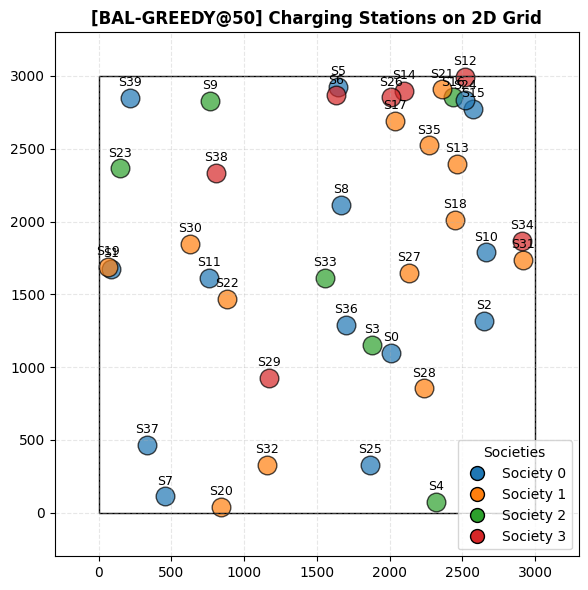

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

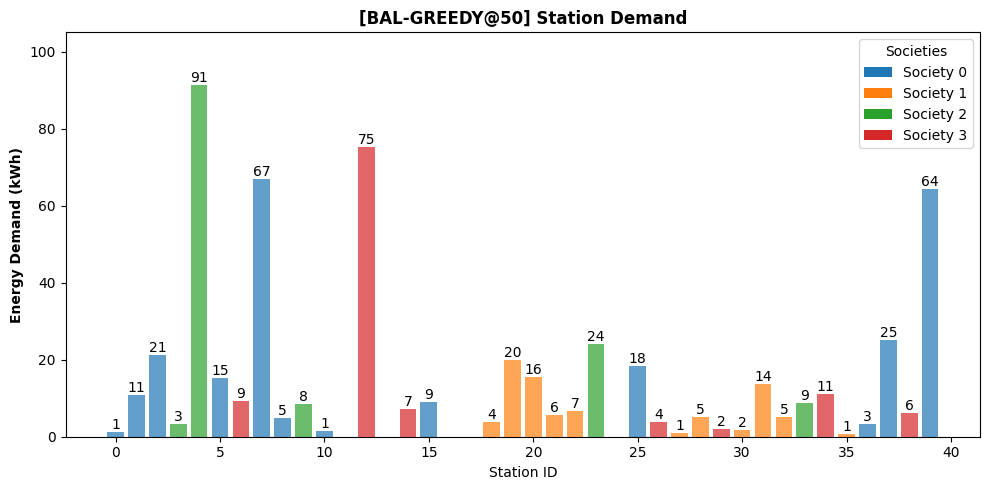

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

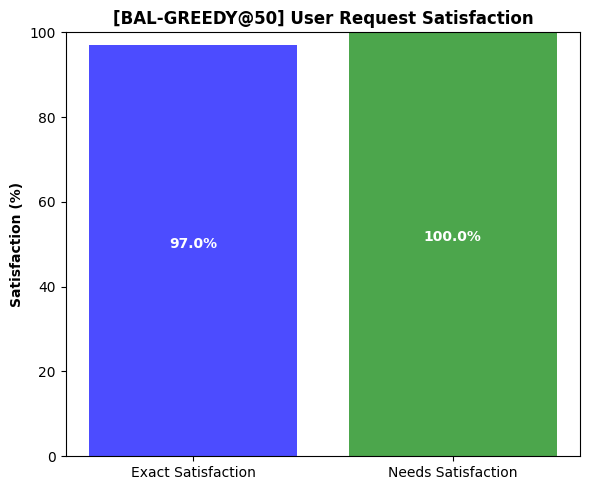

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

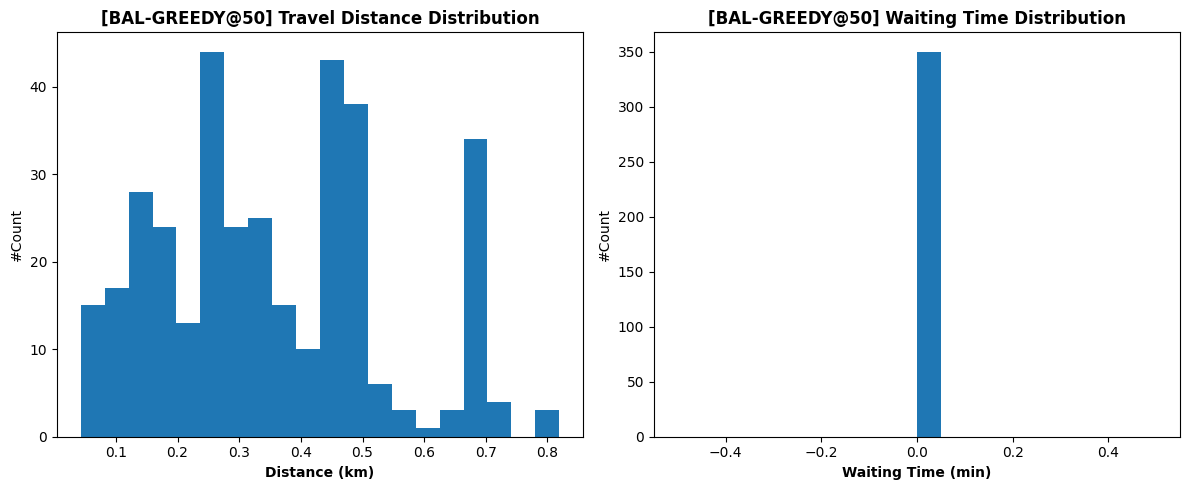

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

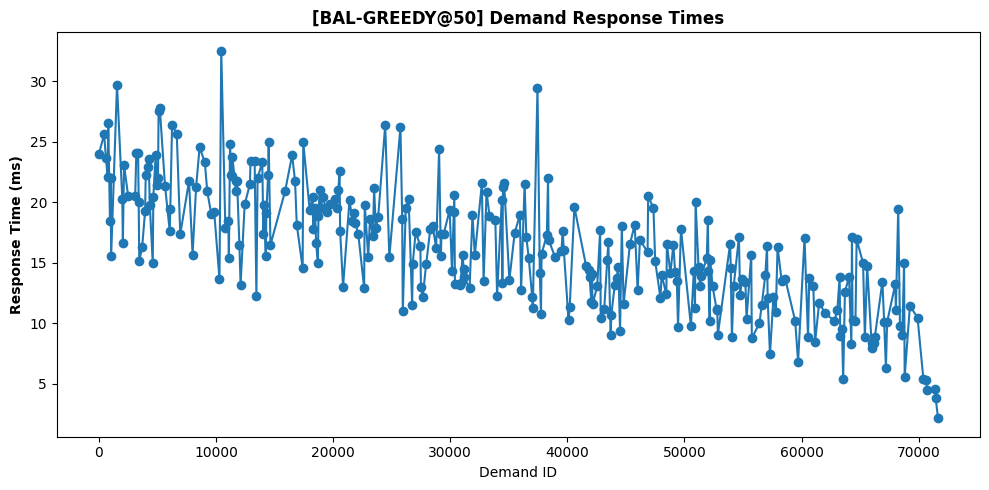

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

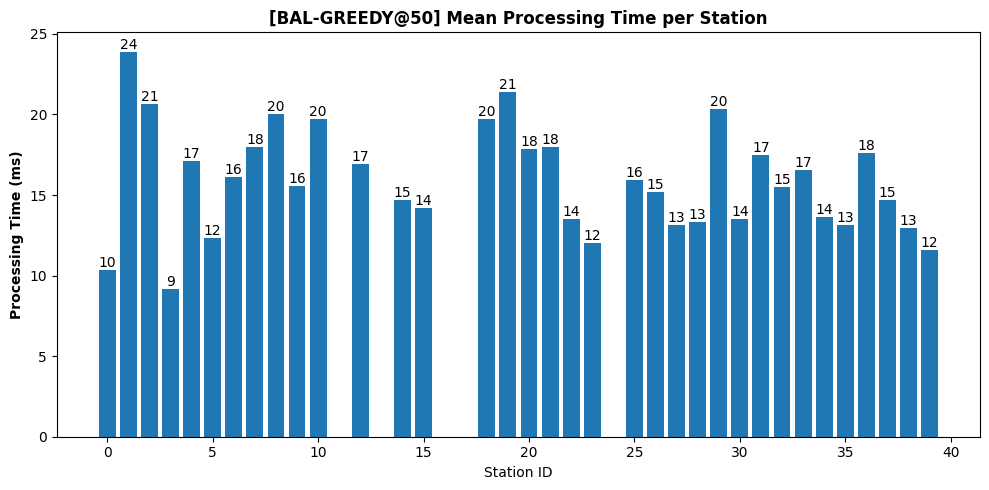

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [ ]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/bramev/50cars


##### *Initialisation*

In [27]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [28]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:11:53.891 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:11:54.191 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:11:54.383 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:11:54.581 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:11:54.779 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:11:55.330 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:11:56.325 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:11:56.761 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:11:57.557 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:11:58.053 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:11:58.712 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [29]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 21.47 kWh
  Station 1: 1.77 kWh
  Station 2: 1.93 kWh
  Station 3: 24.79 kWh
  Station 4: 6.08 kWh
  Station 5: 0.00 kWh
  Station 6: 6.66 kWh
  Station 7: 5.89 kWh
  Station 8: 3.07 kWh
  Station 9: 0.00 kWh
  Station 10: 0.88 kWh
  Station 11: 5.54 kWh
  Station 12: 1.90 kWh
  Station 13: 7.51 kWh
  Station 14: 4.60 kWh
  Station 15: 22.40 kWh
  Station 16: 45.60 kWh
  Station 17: 17.79 kWh
  Station 18: 2.55 kWh
  Station 19: 2.68 kWh
  Station 20: 17.24 kWh
  Station 21: 3.62 kWh
  Station 22: 70.92 kWh
  Station 23: 7.20 kWh
  Station 24: 0.00 kWh
  Station 25: 13.04 kWh
  Station 26: 0.00 kWh
  Station 27: 12.91 kWh
  Station 28: 6.05 kWh
  Station 29: 26.43 kWh
  Station 30: 21.22 kWh
  Station 31: 34.16 kWh
  Station 32: 53.48 kWh
  Station 33: 21.45 kWh
  Station 34: 5.60 kWh
  Station 35: 4.28 kWh
  Station 36: 30.76 kWh
  Station 37: 16.98 kWh
  Station 38: 2.10 kWh
  Station 39: 13.62 kWh

--- User 

In [30]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

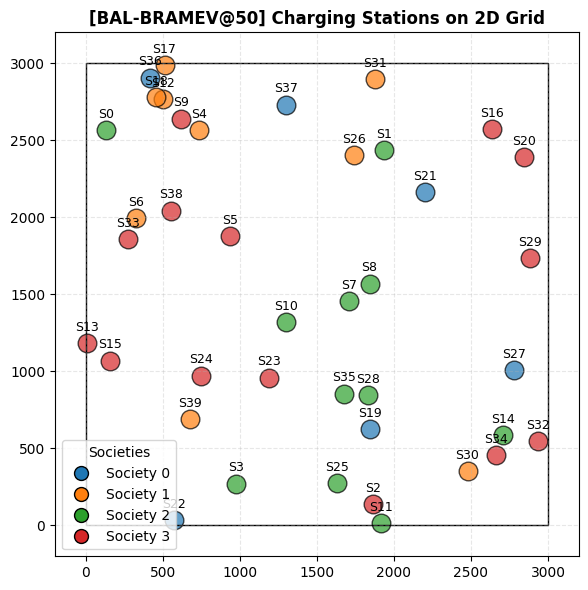

In [31]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

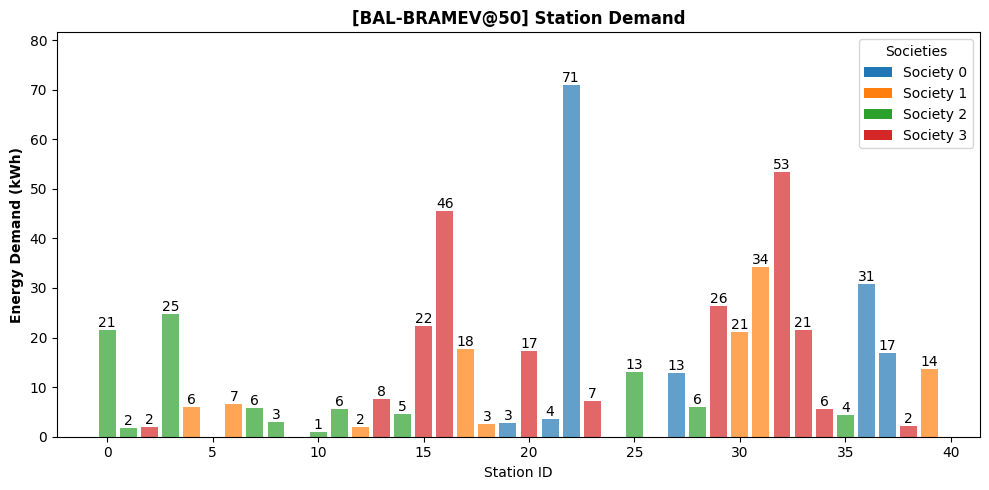

In [32]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

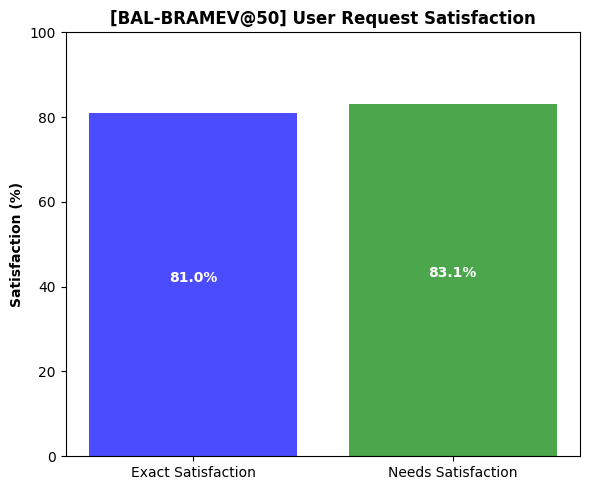

In [33]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

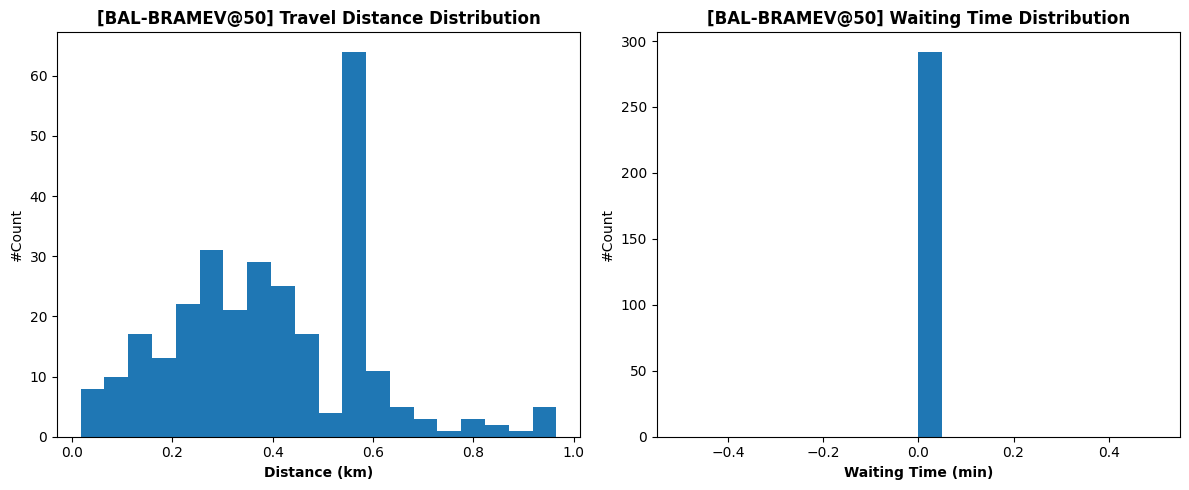

In [34]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

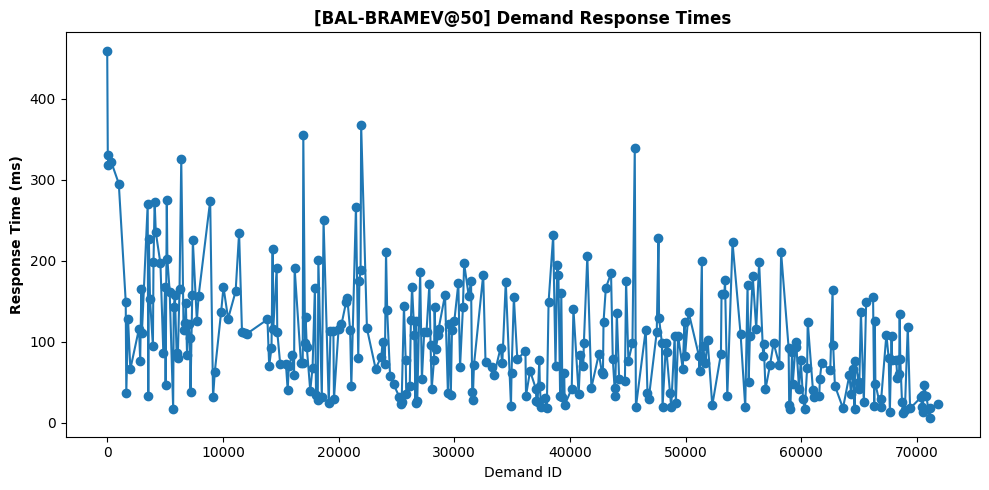

In [35]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

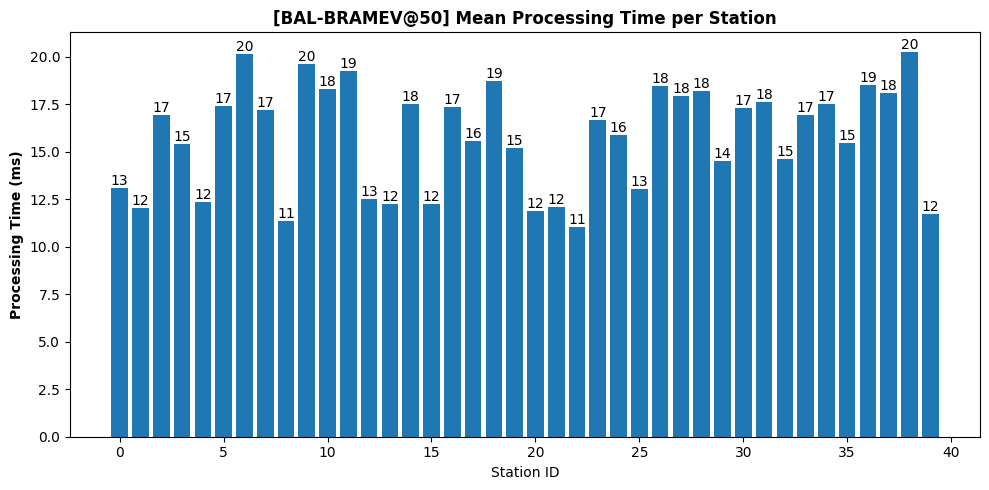

In [36]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

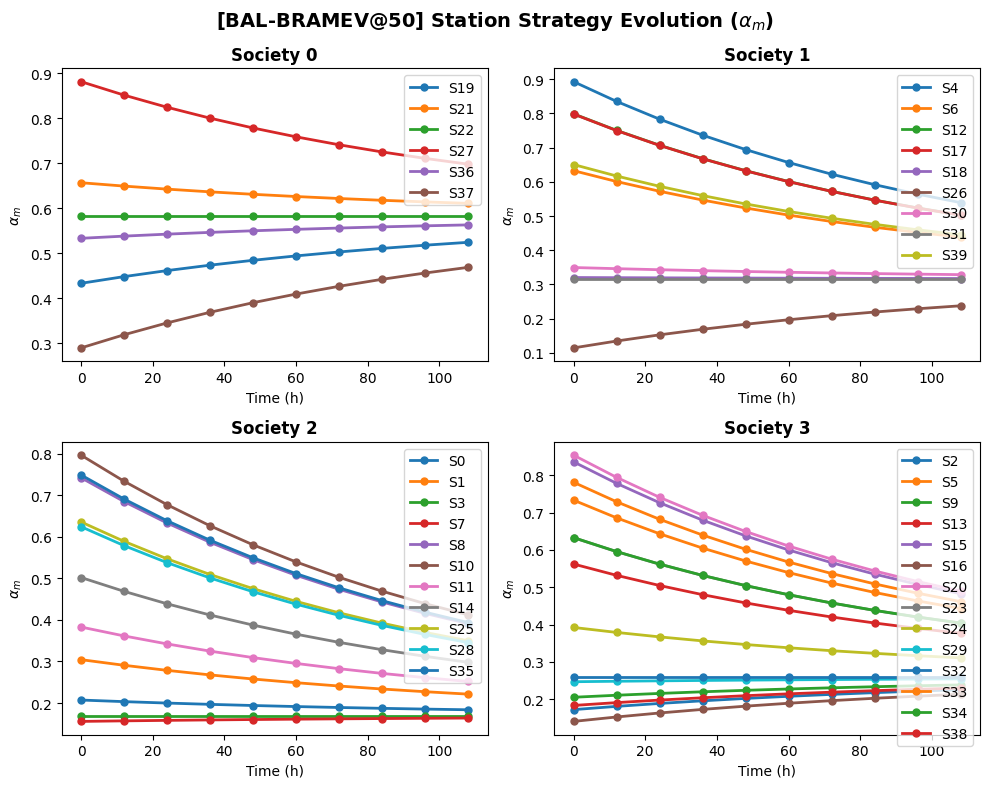

In [37]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [38]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0          19  0.031944  0.000000  0.000000  0.000000  0.000000   
1            0          21  0.043056  0.000000  0.000000  0.000000       NaN   
2            0          22  0.437500  0.375694  0.057639  0.079167       NaN   
3            0          27  0.177778  0.000000  0.000000  0.000000  0.000000   
4            0          36  0.238194  0.104861  0.018056  0.000000  0.000000   
5            0          37  0.171528  0.061111  0.000000  0.000000  0.000000   
6            1           4  0.102083  0.000000  0.000000  0.000000       NaN   
7            1           6  0.082639  0.000000  0.000000  0.000000  0.000000   
8            1          12  0.039583  0.000000  0.000000  0.000000       NaN   
9            1          17  0.254861  0.024306  0.000000  0.000000  0.000000   
10           1          18  0.035417  0.000000  0.000000  0.000000  0.000000   
11           1          26  0.000000  0.

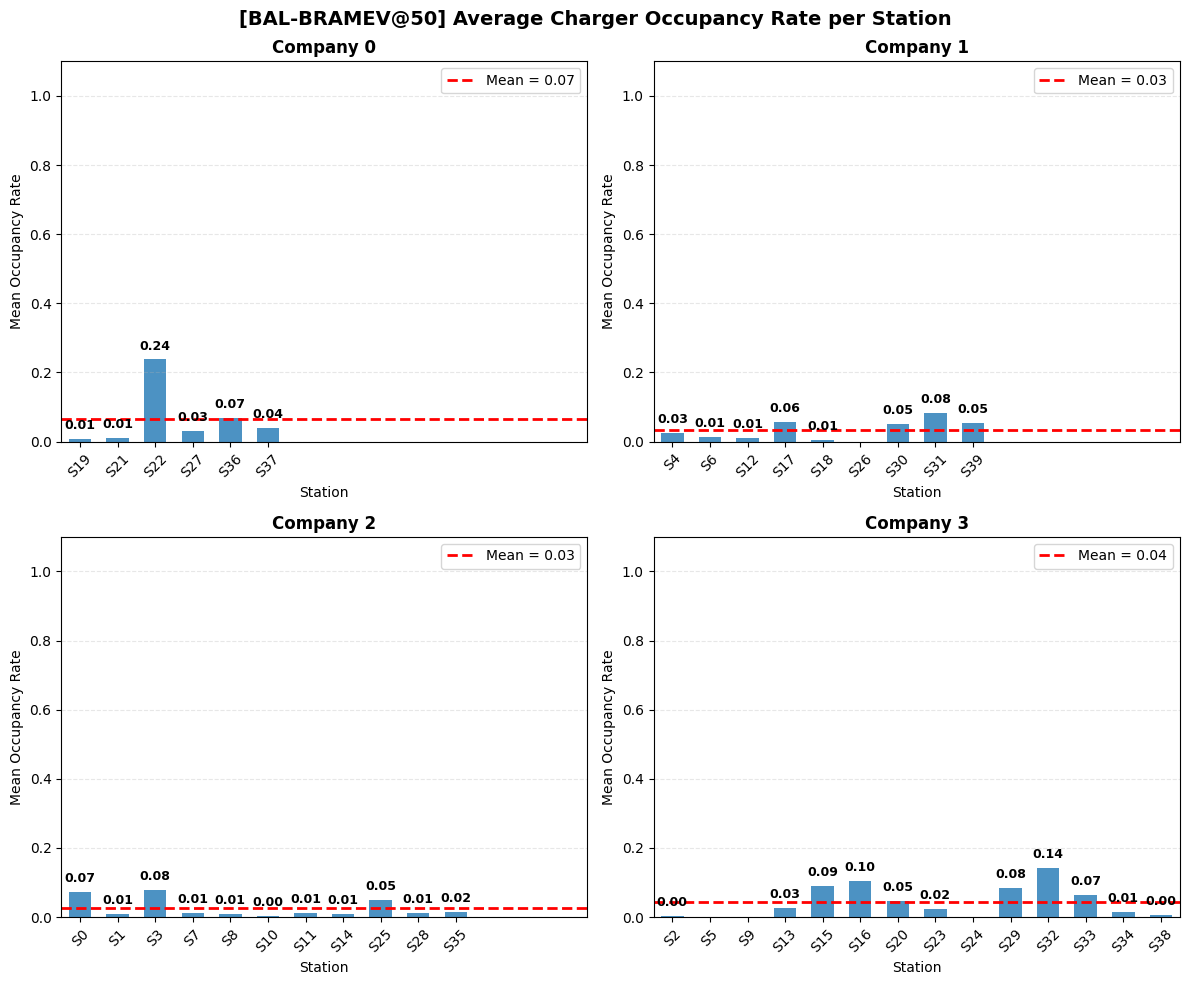

In [39]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

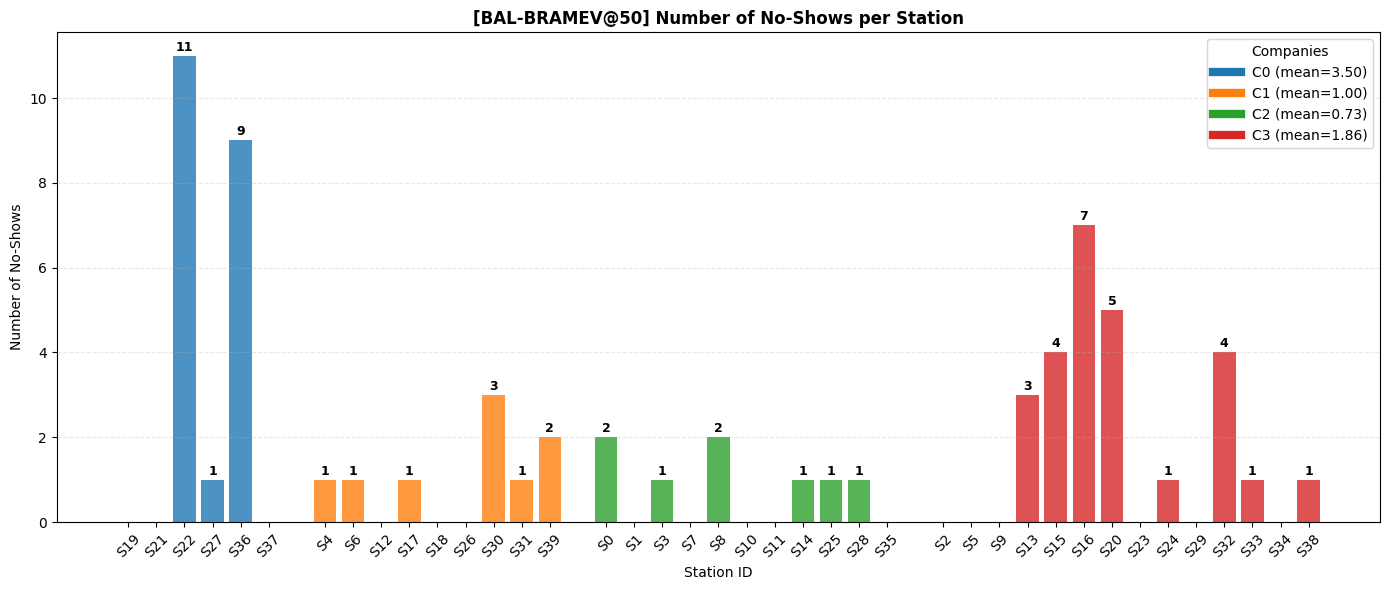

In [40]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [41]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,19,1,1,0,0,0,1.000000,0.000000,0.0,0.0
1,0,21,2,2,0,0,0,1.000000,0.000000,0.0,0.0
2,0,22,50,39,11,0,0,0.780000,0.220000,0.0,0.0
3,0,27,8,7,1,0,0,0.875000,0.125000,0.0,0.0
4,0,36,25,16,9,0,0,0.640000,0.360000,0.0,0.0
5,0,37,9,9,0,0,0,1.000000,0.000000,0.0,0.0
6,1,4,4,3,1,0,0,0.750000,0.250000,0.0,0.0
7,1,6,5,4,1,0,0,0.800000,0.200000,0.0,0.0
8,1,12,1,1,0,0,0,1.000000,0.000000,0.0,0.0
9,1,17,10,9,1,0,0,0.900000,0.100000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [42]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

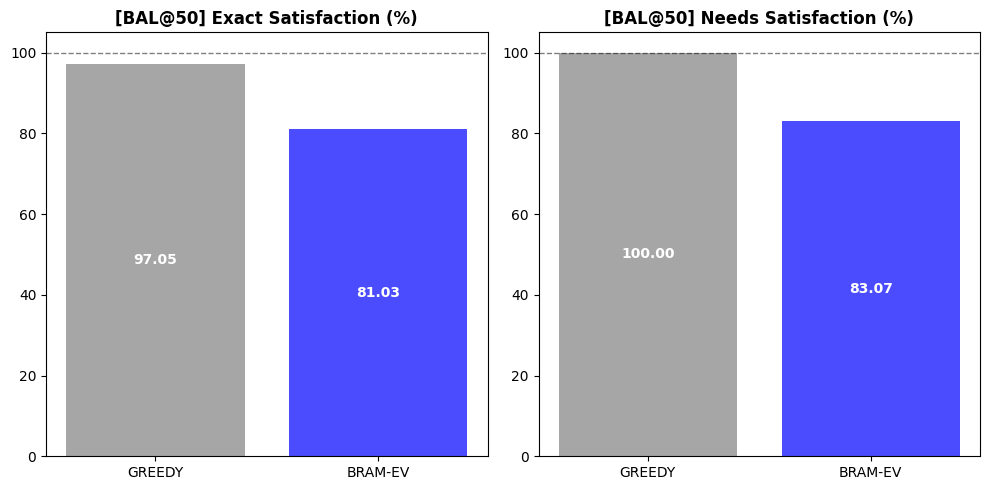

In [43]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

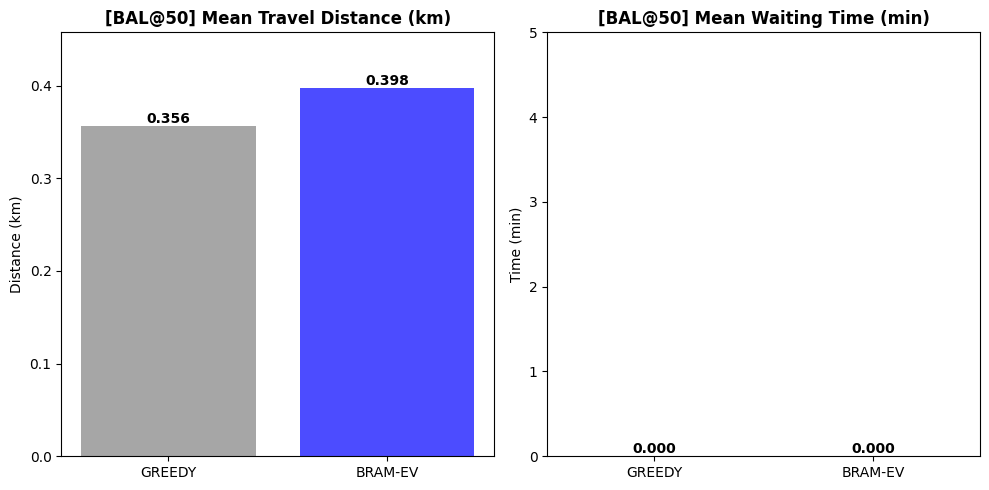

In [44]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

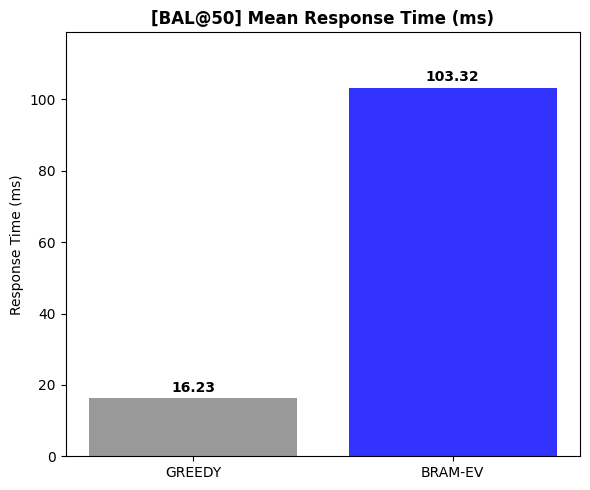

In [45]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [46]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [47]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/100cars


##### *Initialisation*

In [48]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [49]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:12:27.976 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:12:28.157 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:12:28.300 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:12:28.396 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:12:28.445 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:12:28.614 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:12:28.804 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:12:28.866 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:12:28.979 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:12:29.117 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:12:29.310 | IN

##### *Metrics*

In [50]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.20 kWh
  Station 1: 6.75 kWh
  Station 2: 1.80 kWh
  Station 3: 6.03 kWh
  Station 4: 24.77 kWh
  Station 5: 8.18 kWh
  Station 6: 155.48 kWh
  Station 7: 59.34 kWh
  Station 8: 3.75 kWh
  Station 9: 1.27 kWh
  Station 10: 3.25 kWh
  Station 11: 8.88 kWh
  Station 12: 0.00 kWh
  Station 13: 3.18 kWh
  Station 14: 130.93 kWh
  Station 15: 10.82 kWh
  Station 16: 3.69 kWh
  Station 17: 161.72 kWh
  Station 18: 46.46 kWh
  Station 19: 26.84 kWh
  Station 20: 7.83 kWh
  Station 21: 29.25 kWh
  Station 22: 26.82 kWh
  Station 23: 130.97 kWh
  Station 24: 9.19 kWh
  Station 25: 25.60 kWh
  Station 26: 14.00 kWh
  Station 27: 34.77 kWh
  Station 28: 43.40 kWh
  Station 29: 29.96 kWh
  Station 30: 27.43 kWh
  Station 31: 21.87 kWh
  Station 32: 6.64 kWh
  Station 33: 4.55 kWh
  Station 34: 0.00 kWh
  Station 35: 3.93 kWh
  Station 36: 2.35 kWh
  Station 37: 2.98 kWh
  Station 38: 17.89 kWh
  Station 39: 4.92 kWh

--

In [51]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

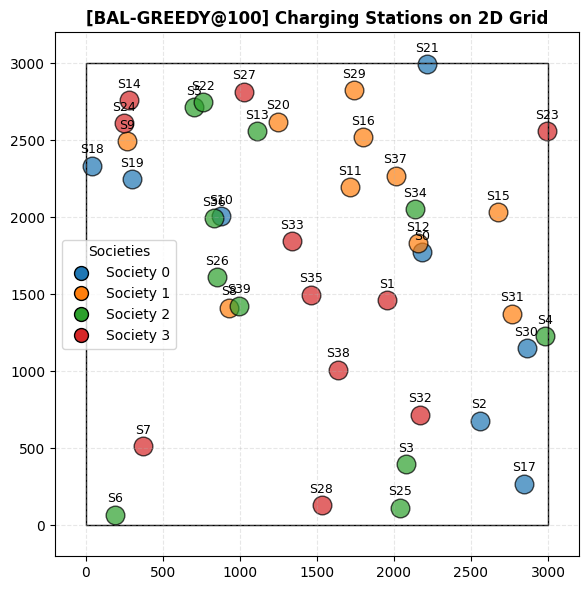

In [52]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

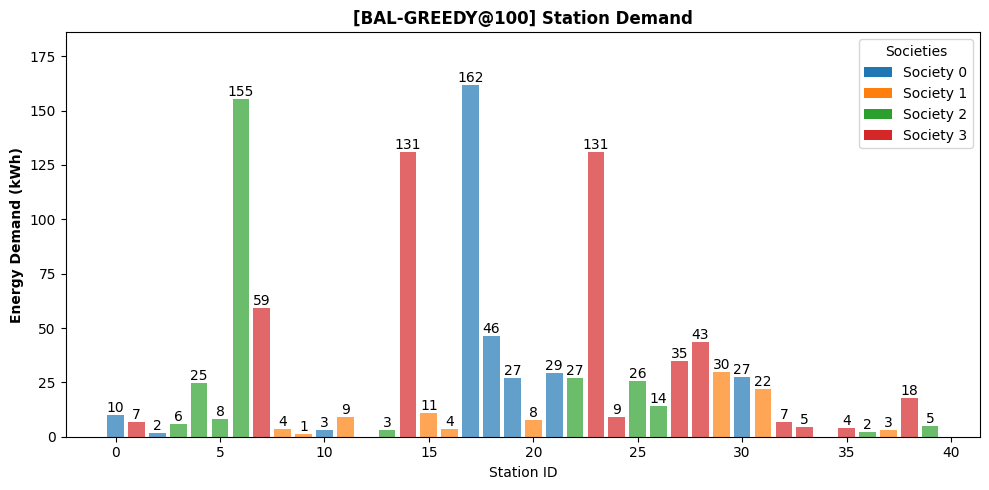

In [53]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

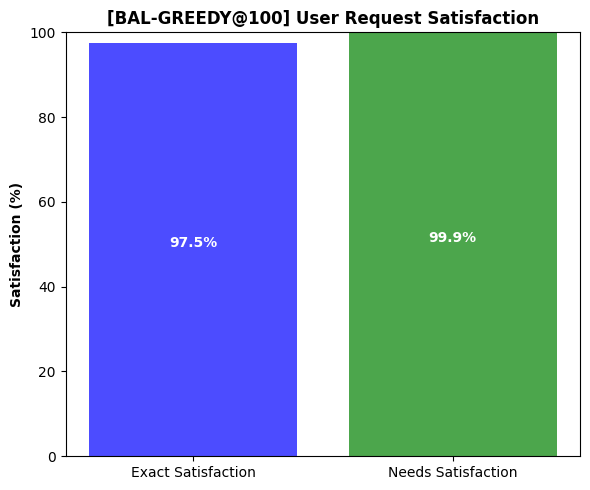

In [54]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

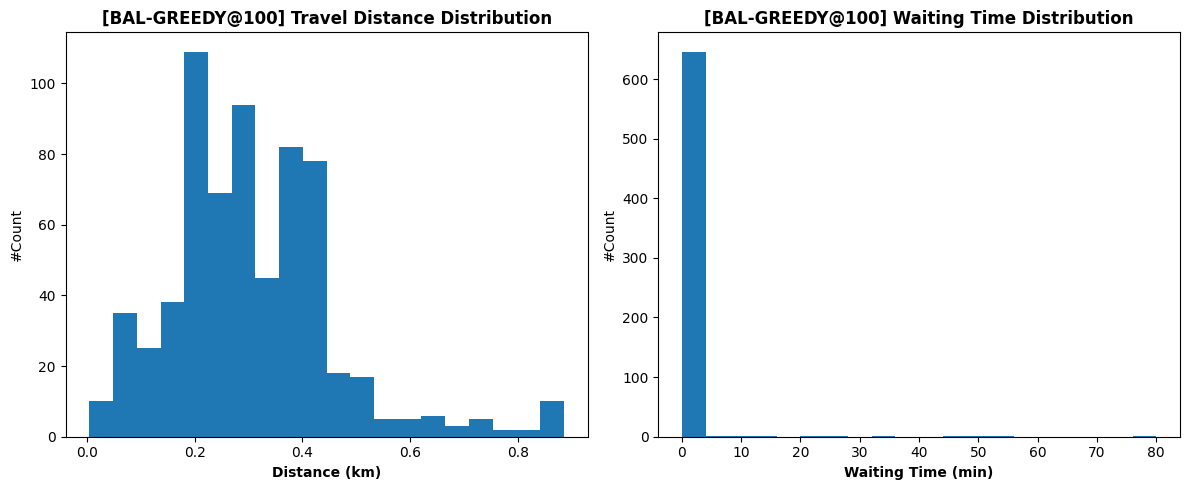

In [55]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

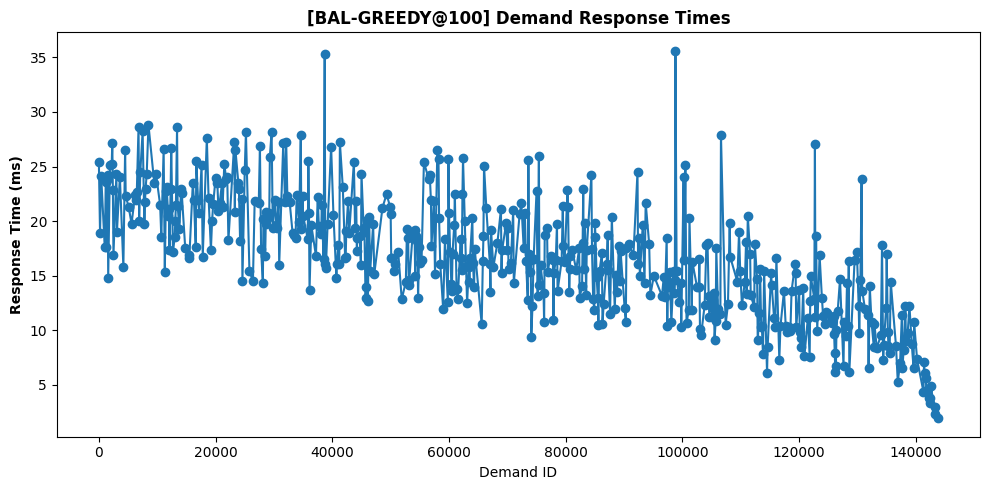

In [56]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

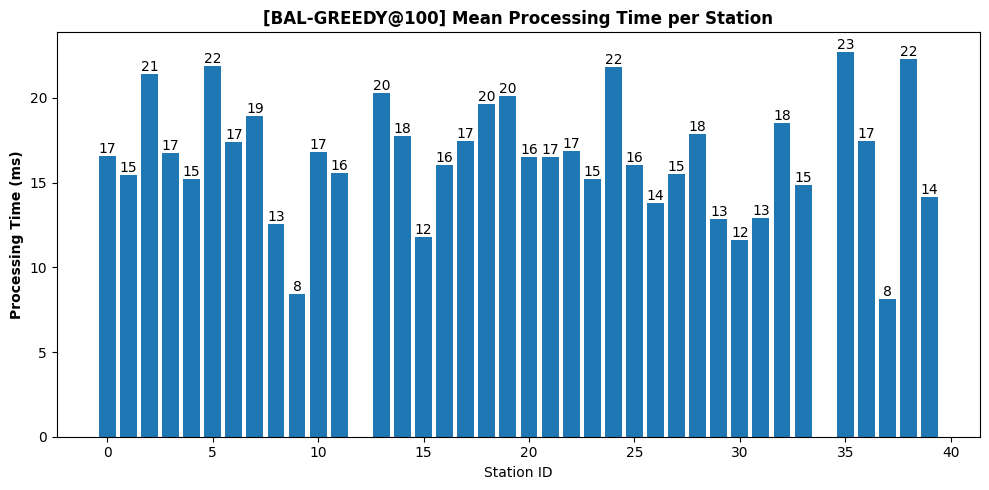

In [57]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [ ]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/bramev/100cars


##### *Initialisation*

In [59]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [60]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:12:41.449 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:12:42.147 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:12:42.671 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:12:43.325 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:12:44.735 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:12:45.583 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:12:47.141 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:12:48.236 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:12:49.341 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:12:50.365 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:12:51.225 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [61]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 61.02 kWh
  Station 1: 3.98 kWh
  Station 2: 2.07 kWh
  Station 3: 0.00 kWh
  Station 4: 14.12 kWh
  Station 5: 107.01 kWh
  Station 6: 3.33 kWh
  Station 7: 29.28 kWh
  Station 8: 33.64 kWh
  Station 9: 1.80 kWh
  Station 10: 47.88 kWh
  Station 11: 104.99 kWh
  Station 12: 9.53 kWh
  Station 13: 8.34 kWh
  Station 14: 5.19 kWh
  Station 15: 6.82 kWh
  Station 16: 134.86 kWh
  Station 17: 4.84 kWh
  Station 18: 9.08 kWh
  Station 19: 0.95 kWh
  Station 20: 3.80 kWh
  Station 21: 18.68 kWh
  Station 22: 3.60 kWh
  Station 23: 19.27 kWh
  Station 24: 10.37 kWh
  Station 25: 0.00 kWh
  Station 26: 19.10 kWh
  Station 27: 25.66 kWh
  Station 28: 3.92 kWh
  Station 29: 10.65 kWh
  Station 30: 40.73 kWh
  Station 31: 7.56 kWh
  Station 32: 38.17 kWh
  Station 33: 27.71 kWh
  Station 34: 30.72 kWh
  Station 35: 38.93 kWh
  Station 36: 5.41 kWh
  Station 37: 0.00 kWh
  Station 38: 42.59 kWh
  Station 39: 125.31 kWh

-

In [62]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

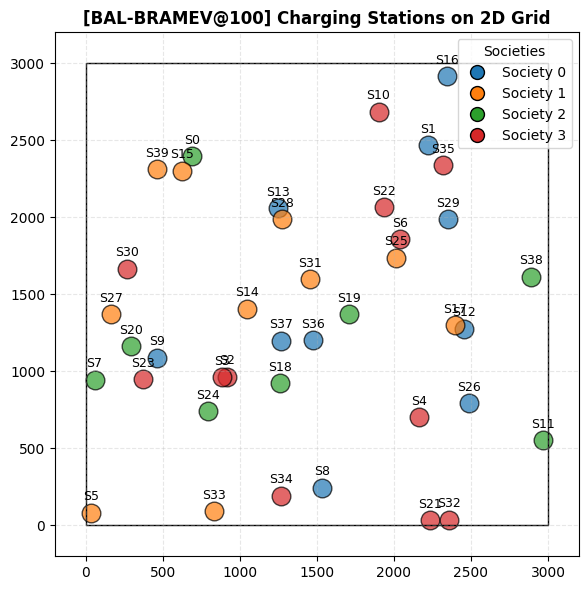

In [63]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

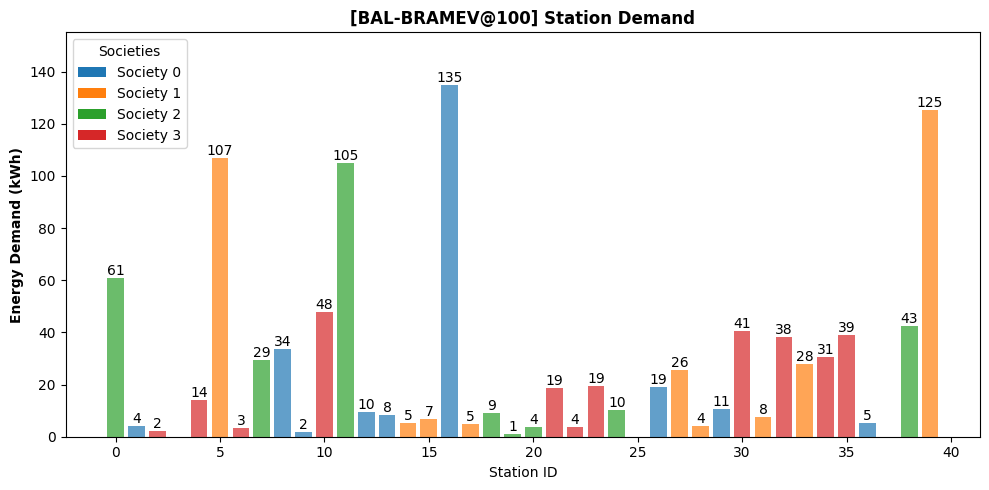

In [64]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

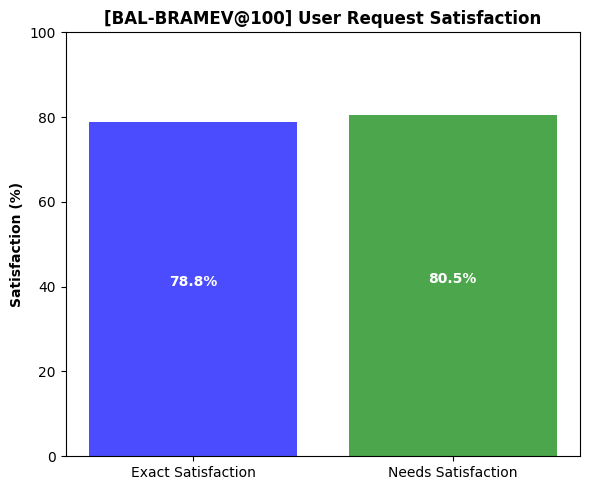

In [65]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

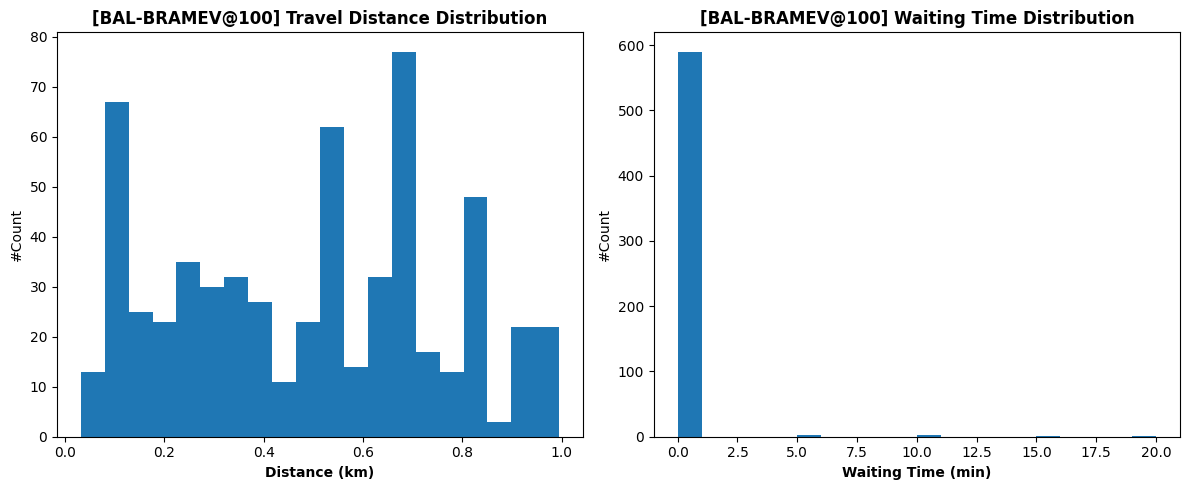

In [66]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

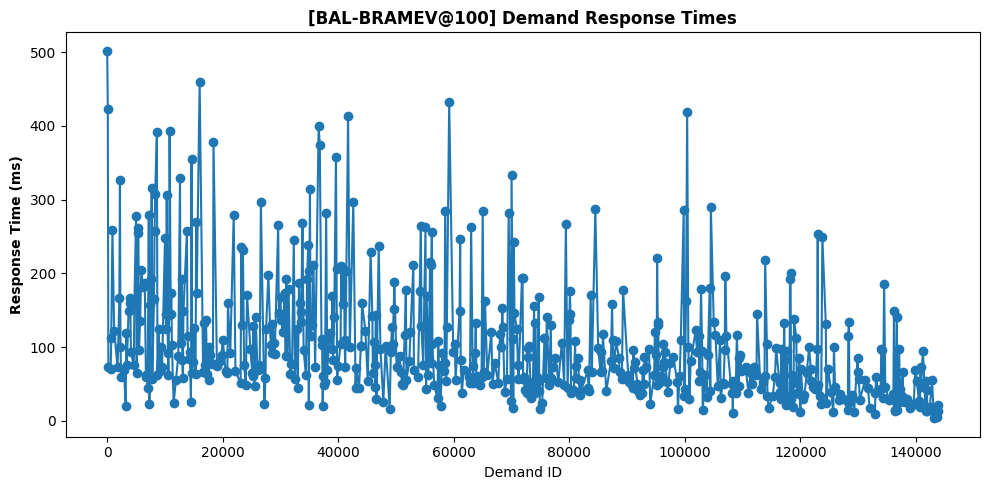

In [67]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

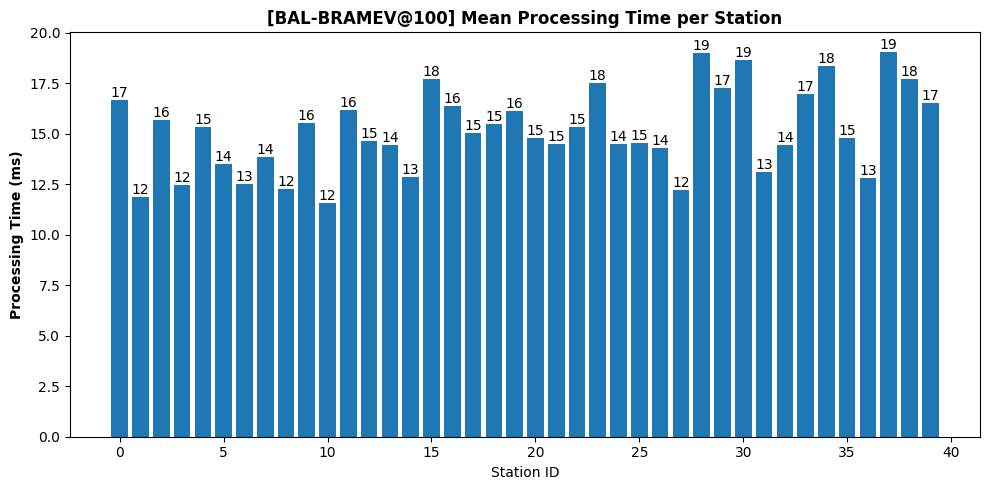

In [68]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

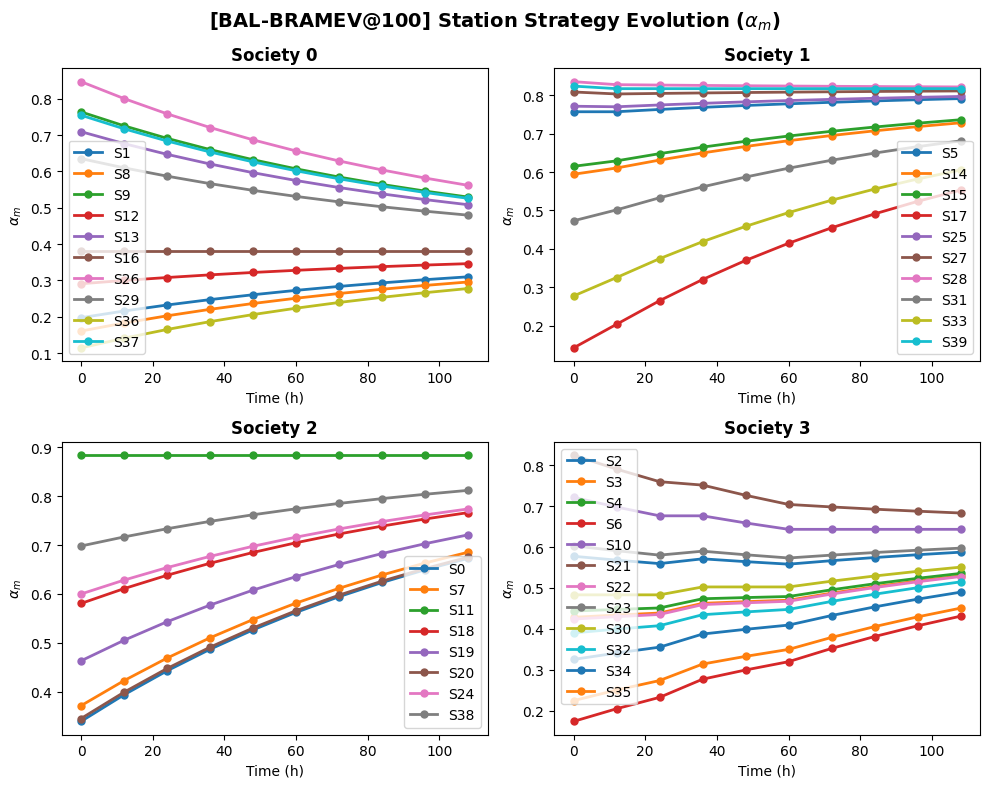

In [69]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [70]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.067361  0.000000  0.000000  0.000000       NaN   
1            0           8  0.396528  0.082639  0.031250  0.000000       NaN   
2            0           9  0.018750  0.000000  0.000000  0.000000  0.000000   
3            0          12  0.097222  0.056250  0.000000  0.000000  0.000000   
4            0          13  0.117361  0.018056  0.000000  0.000000  0.000000   
5            0          16  0.589583  0.570833  0.227083  0.100694  0.125694   
6            0          26  0.169444  0.035417  0.012500  0.000000  0.000000   
7            0          29  0.145833  0.000000  0.000000  0.000000  0.000000   
8            0          36  0.040972  0.039583  0.000000  0.000000       NaN   
9            0          37  0.000000  0.000000  0.000000  0.000000  0.000000   
10           1           5  0.606250  0.429861  0.193750  0.131250  0.223611   
11           1          14  0.076389  0.

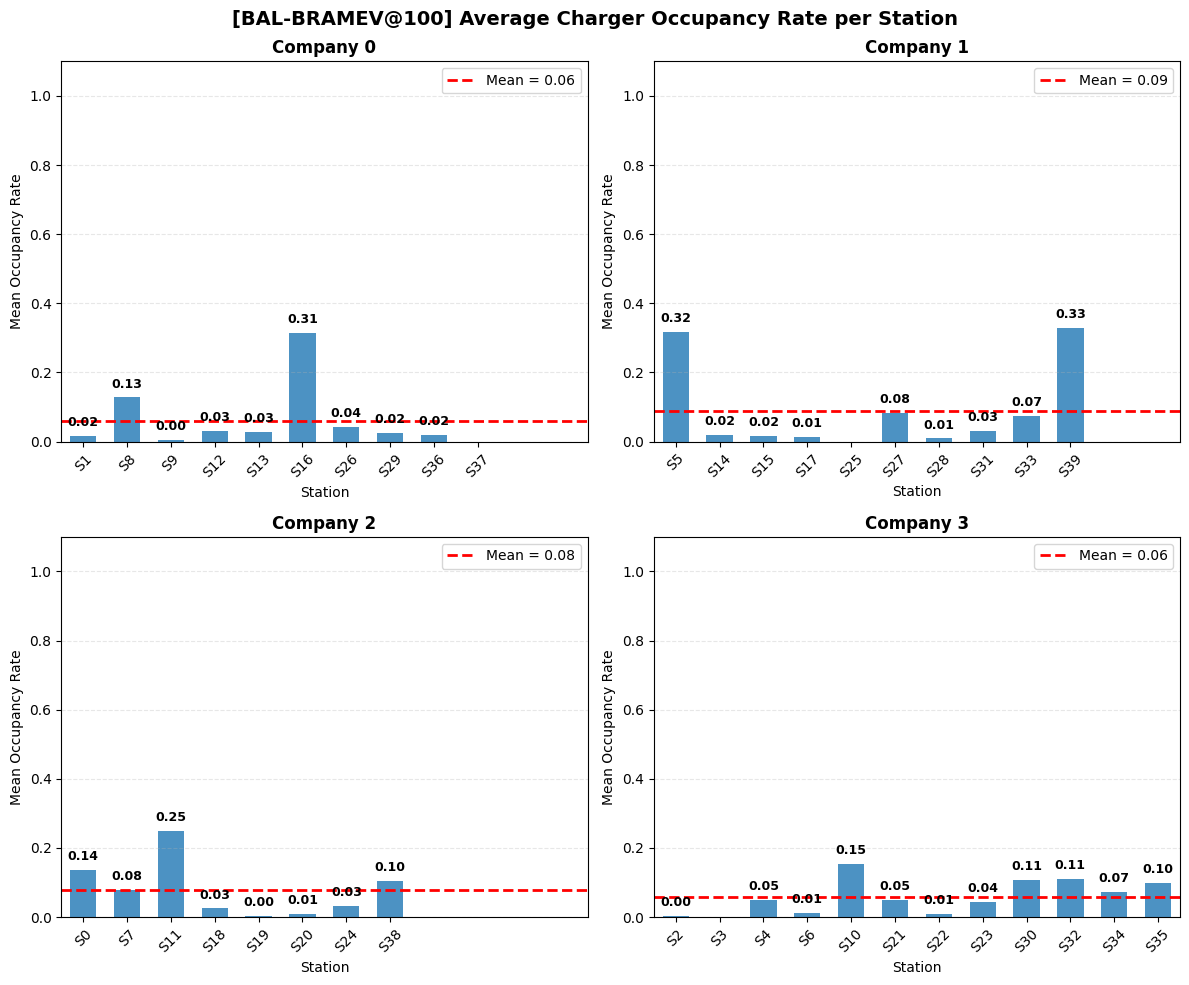

In [71]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

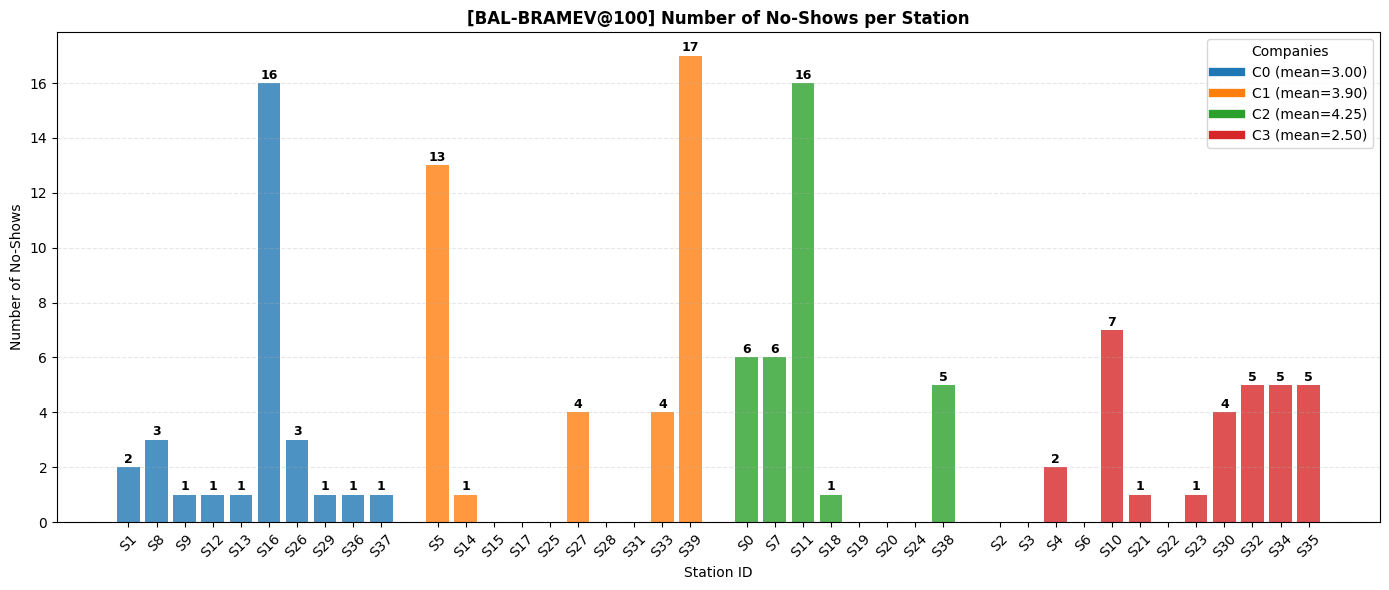

In [72]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [73]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,4,2,2,0,0,0.500000,0.500000,0.0,0.0
1,0,8,21,18,3,0,0,0.857143,0.142857,0.0,0.0
2,0,9,2,1,1,0,0,0.500000,0.500000,0.0,0.0
3,0,12,7,5,1,0,0,0.714286,0.142857,0.0,0.0
4,0,13,6,5,1,0,0,0.833333,0.166667,0.0,0.0
5,0,16,89,72,16,0,0,0.808989,0.179775,0.0,0.0
6,0,26,14,11,3,0,0,0.785714,0.214286,0.0,0.0
7,0,29,7,6,1,0,0,0.857143,0.142857,0.0,0.0
8,0,36,4,3,1,0,0,0.750000,0.250000,0.0,0.0
9,0,37,1,0,1,0,0,0.000000,1.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [74]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

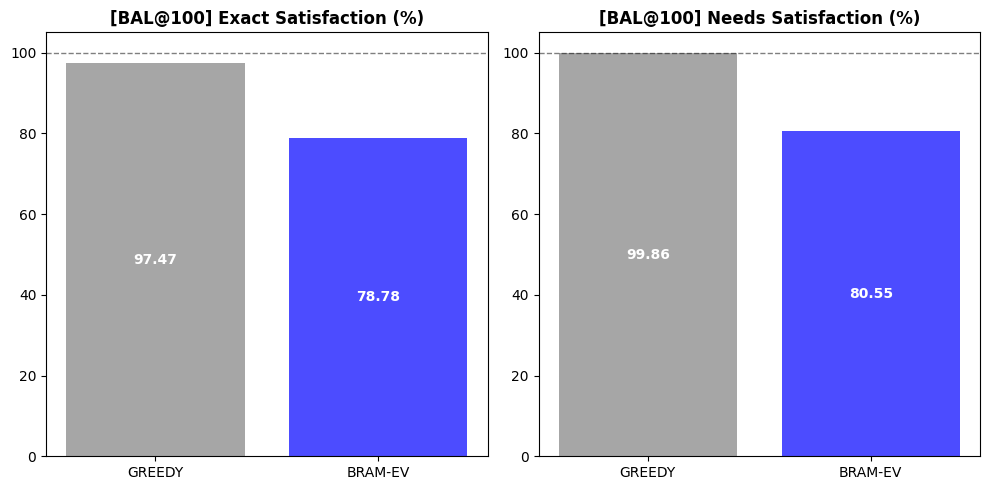

In [75]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

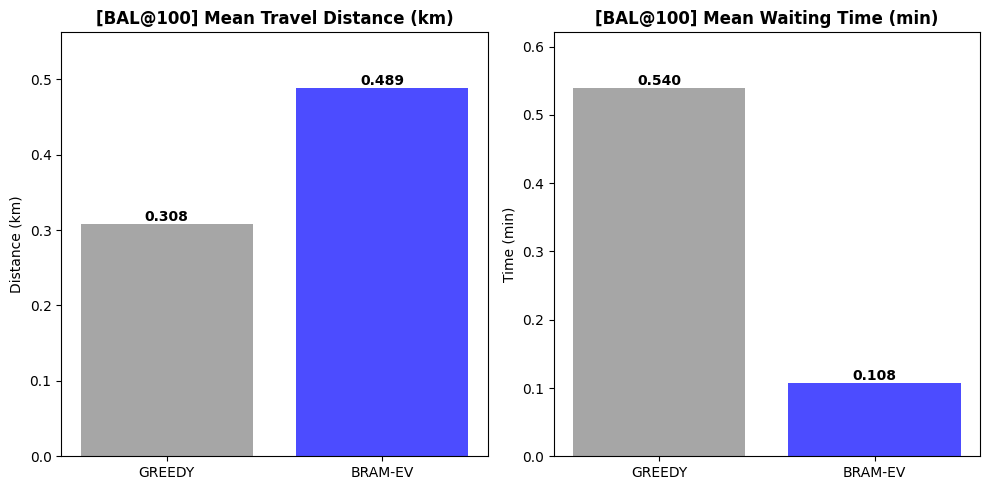

In [76]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

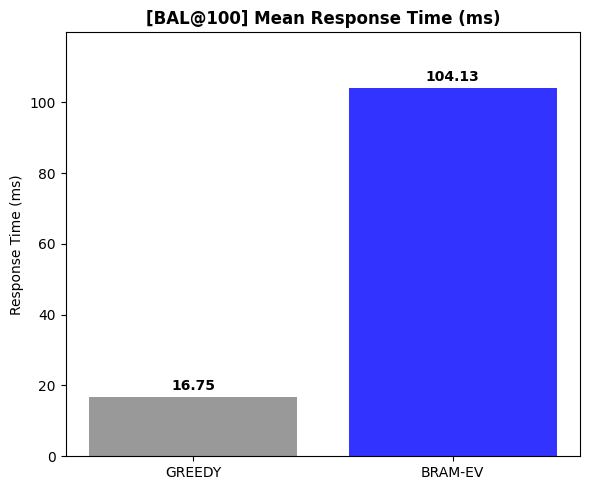

In [77]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [78]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [79]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/150cars


##### *Initialisation*

In [80]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [81]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:13:45.964 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:13:46.165 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:13:46.352 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:13:46.605 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:13:46.823 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:13:47.155 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:13:47.343 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:13:47.493 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:13:47.632 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:13:47.797 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:13:47.944 | IN

##### *Metrics*

In [82]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.49 kWh
  Station 1: 7.45 kWh
  Station 2: 0.00 kWh
  Station 3: 2.45 kWh
  Station 4: 12.84 kWh
  Station 5: 55.20 kWh
  Station 6: 79.04 kWh
  Station 7: 0.93 kWh
  Station 8: 0.00 kWh
  Station 9: 62.92 kWh
  Station 10: 4.07 kWh
  Station 11: 2.83 kWh
  Station 12: 2.40 kWh
  Station 13: 184.78 kWh
  Station 14: 6.13 kWh
  Station 15: 54.20 kWh
  Station 16: 274.93 kWh
  Station 17: 3.64 kWh
  Station 18: 2.30 kWh
  Station 19: 5.67 kWh
  Station 20: 9.32 kWh
  Station 21: 210.96 kWh
  Station 22: 26.62 kWh
  Station 23: 0.00 kWh
  Station 24: 5.17 kWh
  Station 25: 3.73 kWh
  Station 26: 25.05 kWh
  Station 27: 1.12 kWh
  Station 28: 81.66 kWh
  Station 29: 7.08 kWh
  Station 30: 30.89 kWh
  Station 31: 1.87 kWh
  Station 32: 3.78 kWh
  Station 33: 61.29 kWh
  Station 34: 6.92 kWh
  Station 35: 20.17 kWh
  Station 36: 235.45 kWh
  Station 37: 59.36 kWh
  Station 38: 2.67 kWh
  Station 39: 65.36 kWh

--- 

In [83]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

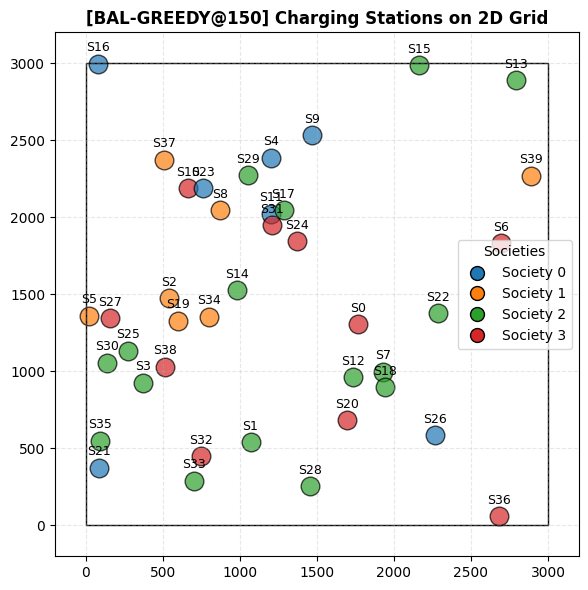

In [84]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

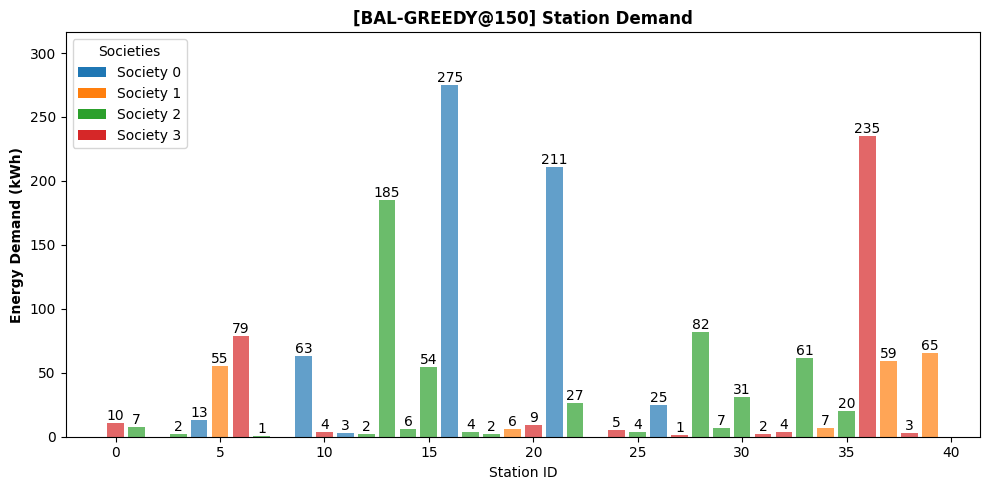

In [85]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

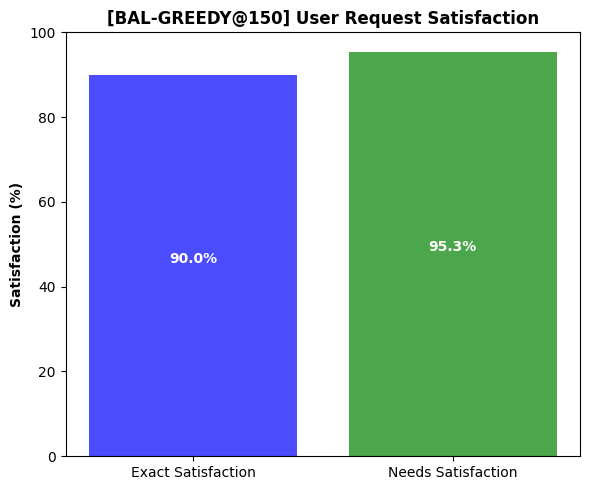

In [86]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

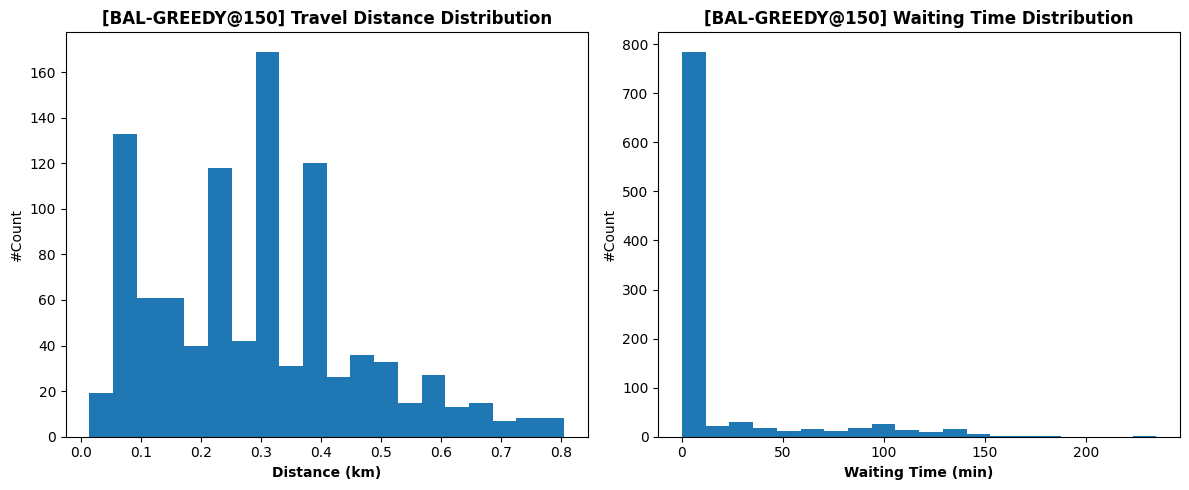

In [87]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

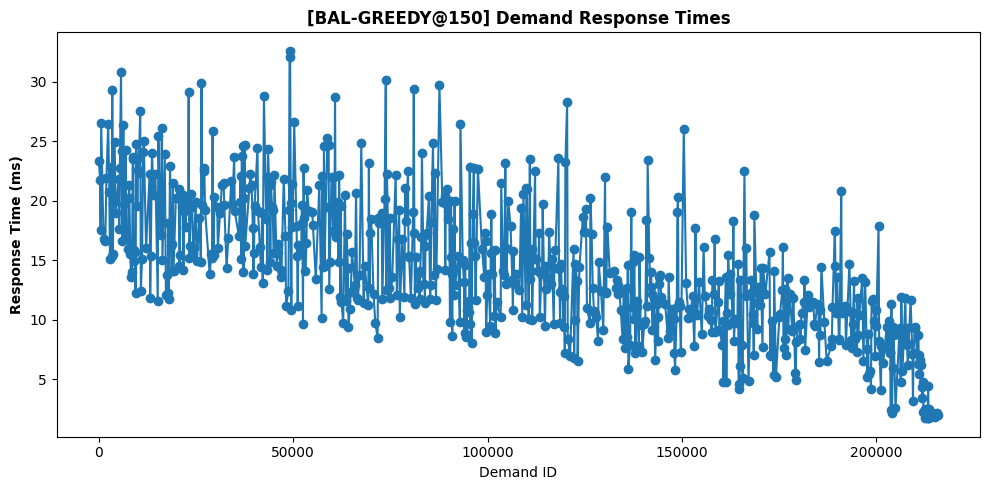

In [88]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

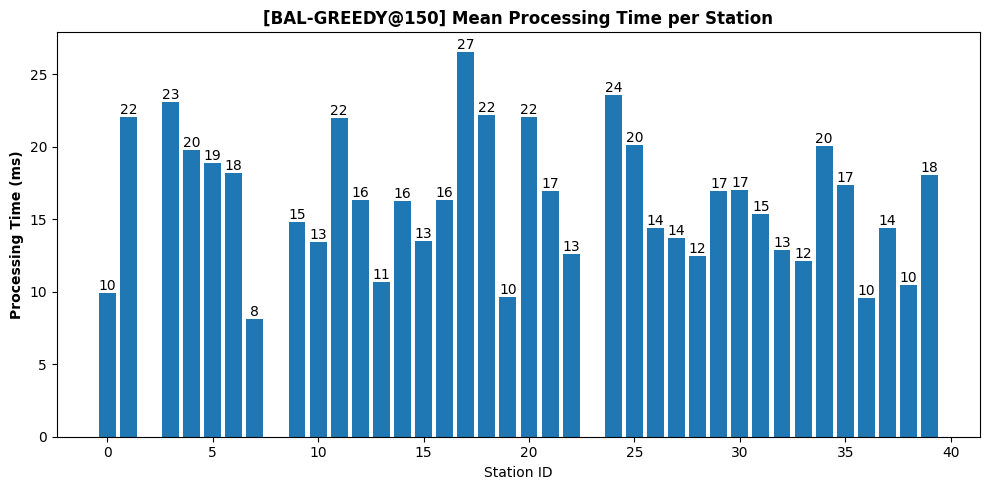

In [89]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [90]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [91]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [92]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:14:07.408 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:14:07.888 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:14:09.336 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:14:10.667 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:14:11.445 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:14:12.594 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:14:13.770 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:14:15.369 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:14:16.125 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:14:18.198 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:14:19.829 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [93]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 150.19 kWh
  Station 1: 49.47 kWh
  Station 2: 9.82 kWh
  Station 3: 14.03 kWh
  Station 4: 139.37 kWh
  Station 5: 40.99 kWh
  Station 6: 81.56 kWh
  Station 7: 1.62 kWh
  Station 8: 12.75 kWh
  Station 9: 13.60 kWh
  Station 10: 15.05 kWh
  Station 11: 35.07 kWh
  Station 12: 7.72 kWh
  Station 13: 76.53 kWh
  Station 14: 43.68 kWh
  Station 15: 45.39 kWh
  Station 16: 35.39 kWh
  Station 17: 10.53 kWh
  Station 18: 180.38 kWh
  Station 19: 3.37 kWh
  Station 20: 5.62 kWh
  Station 21: 8.19 kWh
  Station 22: 80.03 kWh
  Station 23: 10.13 kWh
  Station 24: 5.13 kWh
  Station 25: 6.92 kWh
  Station 26: 44.22 kWh
  Station 27: 13.19 kWh
  Station 28: 11.08 kWh
  Station 29: 22.28 kWh
  Station 30: 10.21 kWh
  Station 31: 88.18 kWh
  Station 32: 5.78 kWh
  Station 33: 18.83 kWh
  Station 34: 68.49 kWh
  Station 35: 1.42 kWh
  Station 36: 42.42 kWh
  Station 37: 192.62 kWh
  Station 38: 3.62 kWh
  Station 39: 17.6

In [94]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

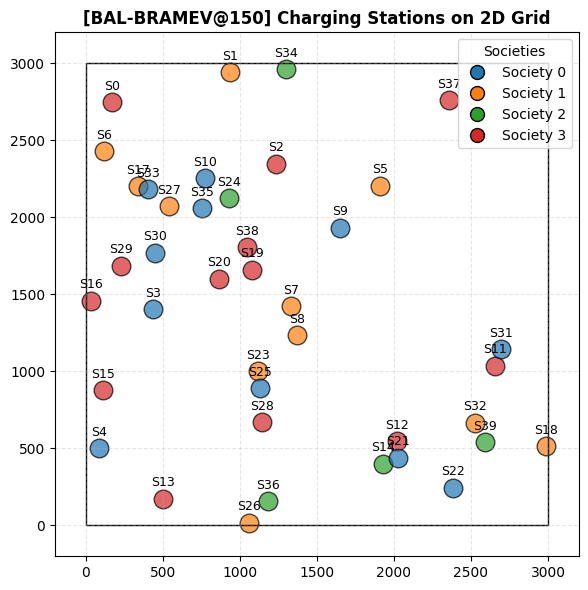

In [95]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

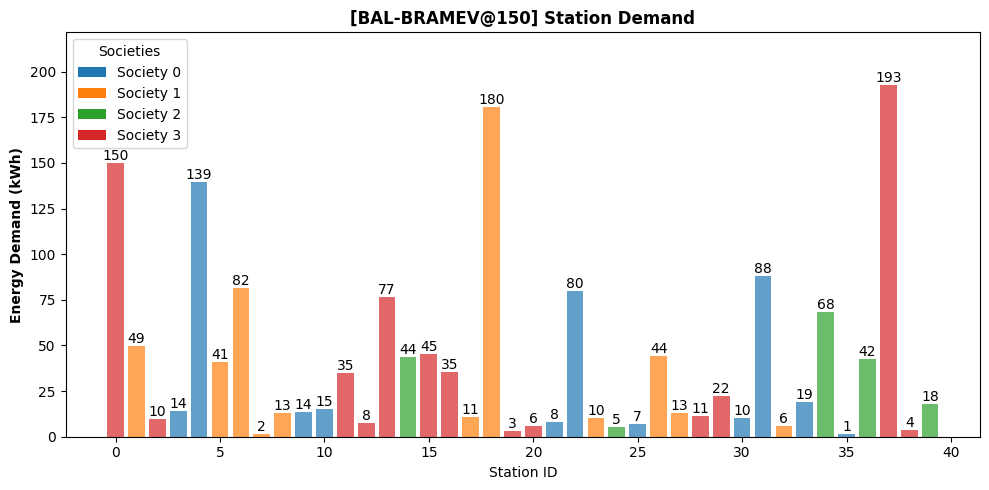

In [96]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

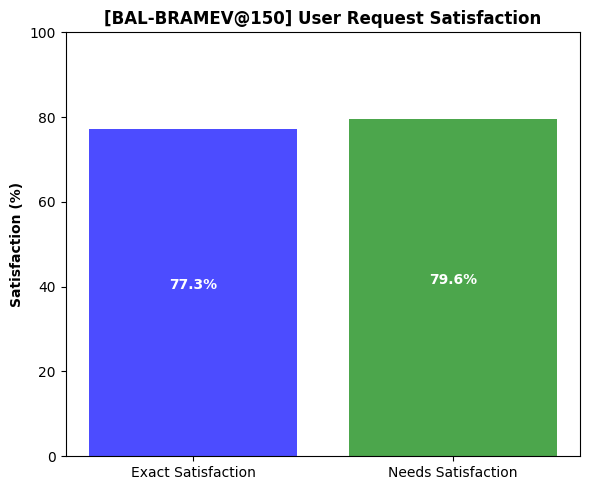

In [97]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

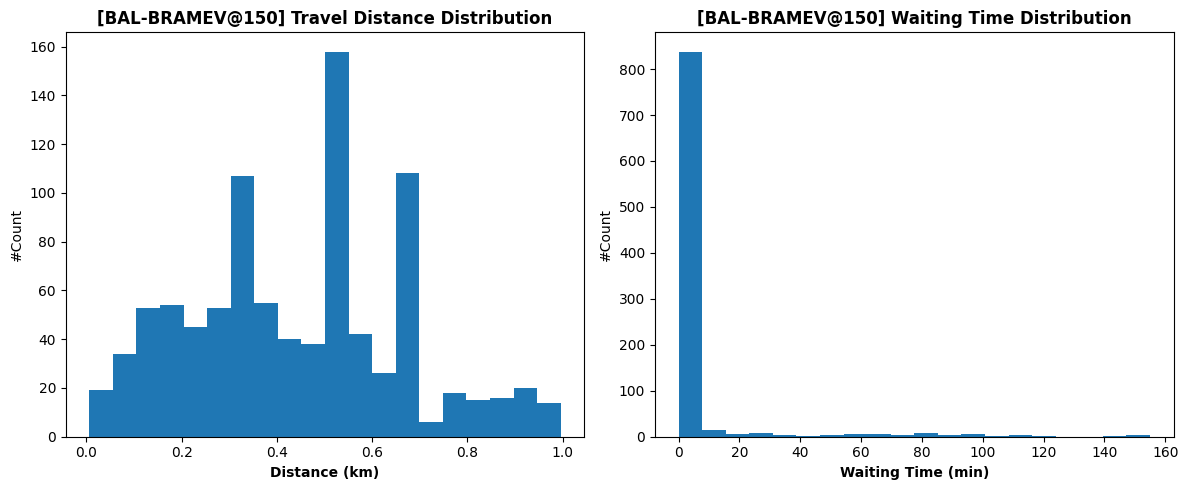

In [98]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

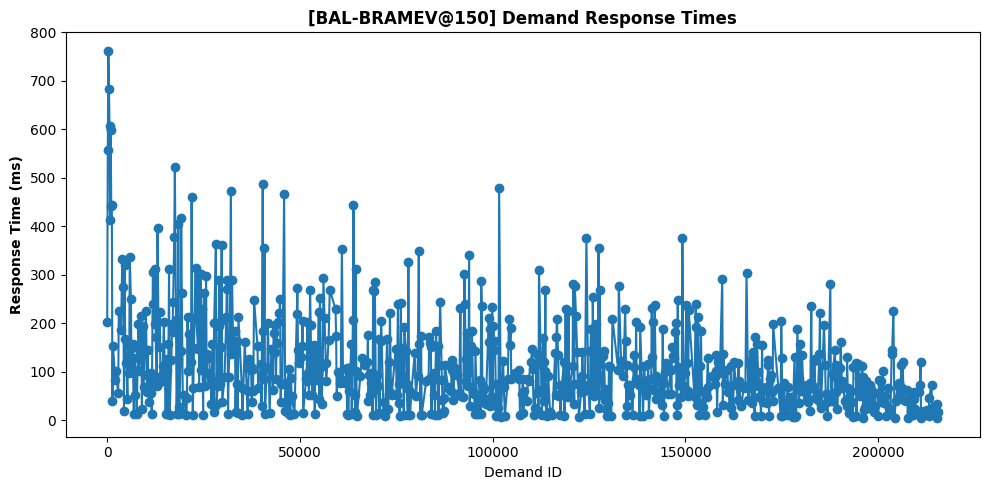

In [99]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

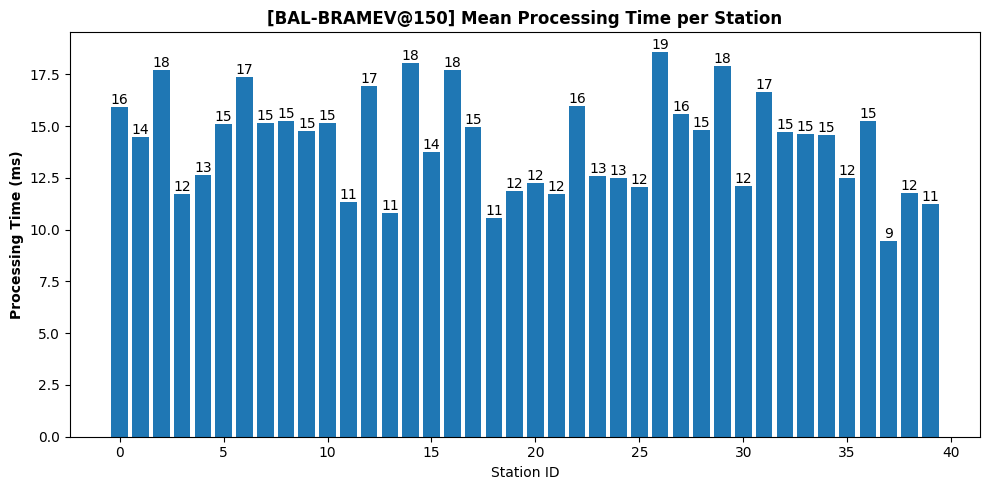

In [100]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

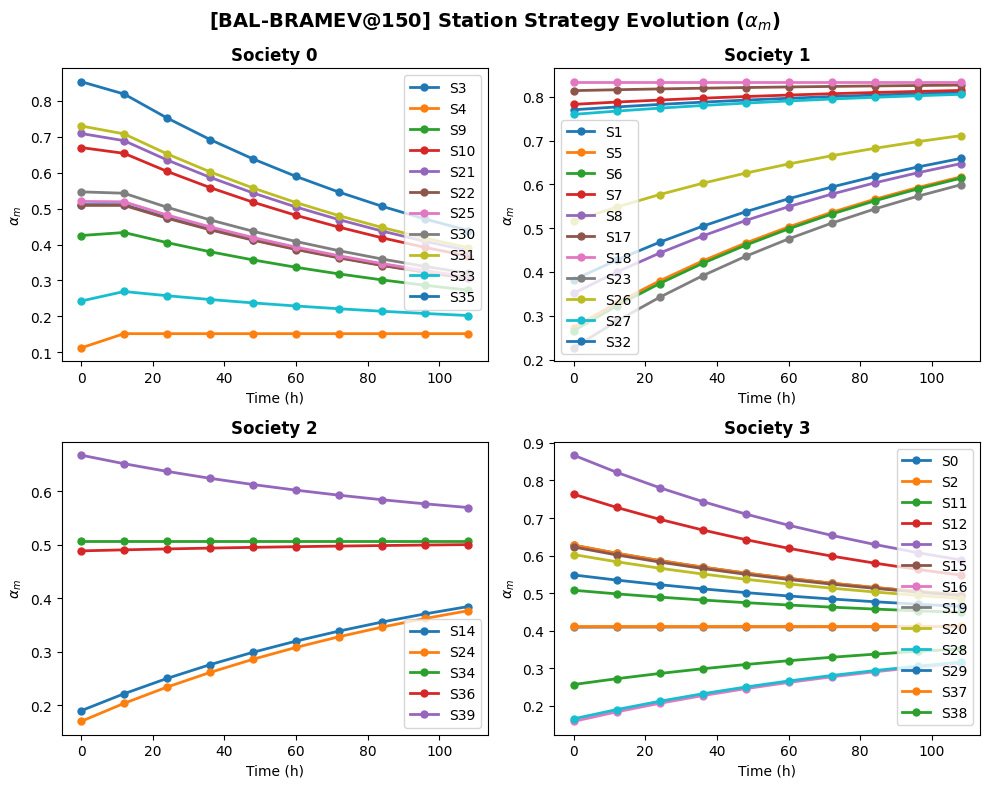

In [101]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [102]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.183333  0.029167  0.000000  0.000000       NaN   
1            0           4  0.629167  0.461111  0.295833  0.356250  0.310417   
2            0           9  0.140278  0.019444  0.000000  0.000000  0.000000   
3            0          10  0.209028  0.045139  0.000000  0.000000  0.000000   
4            0          21  0.073611  0.020139  0.000000  0.000000       NaN   
5            0          22  0.534722  0.358333  0.078472  0.025000  0.027778   
6            0          25  0.060417  0.051389  0.000000  0.000000       NaN   
7            0          30  0.127778  0.035417  0.000000  0.000000       NaN   
8            0          31  0.570833  0.346528  0.100000  0.041667  0.063889   
9            0          33  0.279167  0.033333  0.000000  0.000000  0.000000   
10           0          35  0.023611  0.000000  0.000000  0.000000       NaN   
11           1           1  0.503472  0.

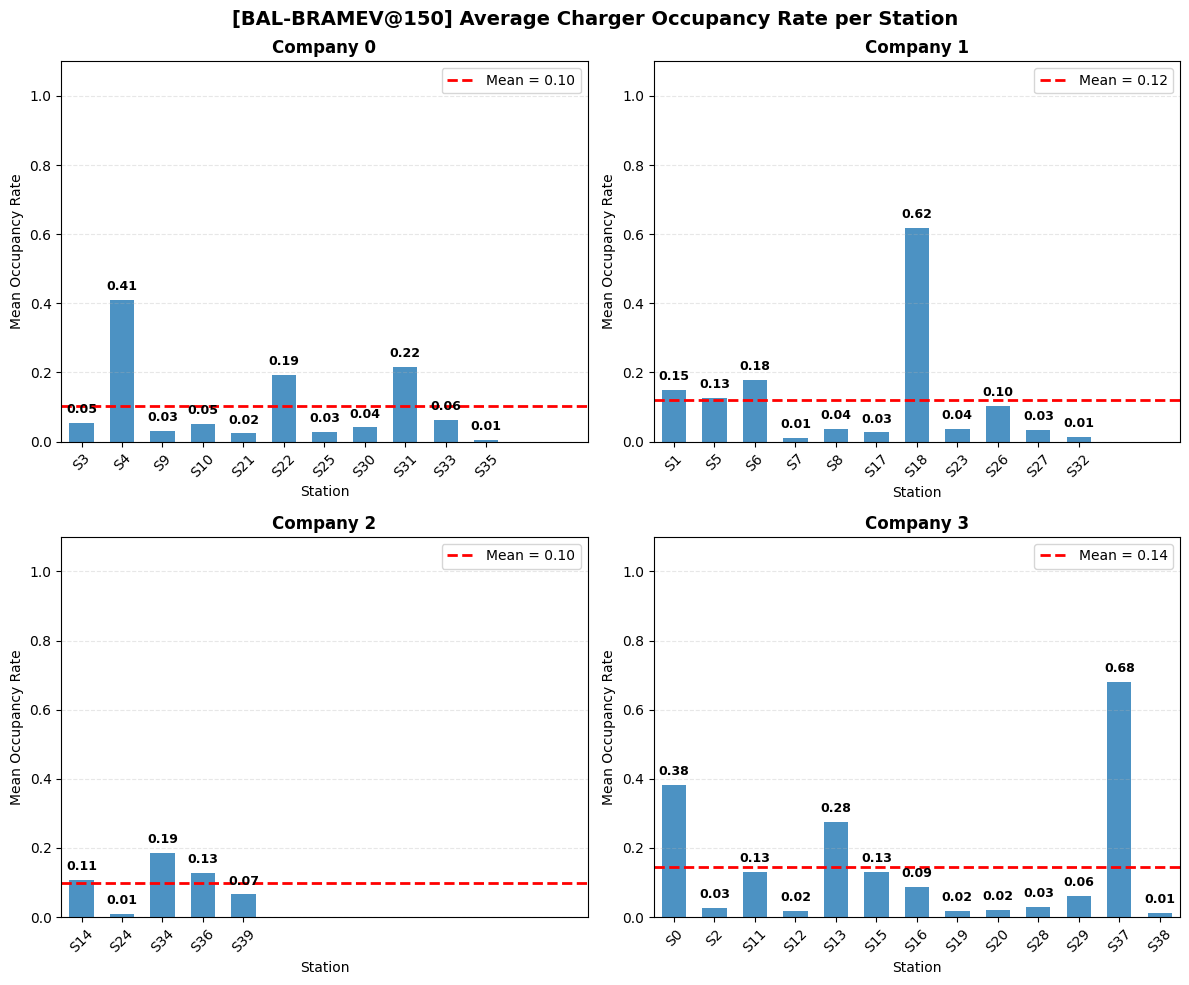

In [103]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

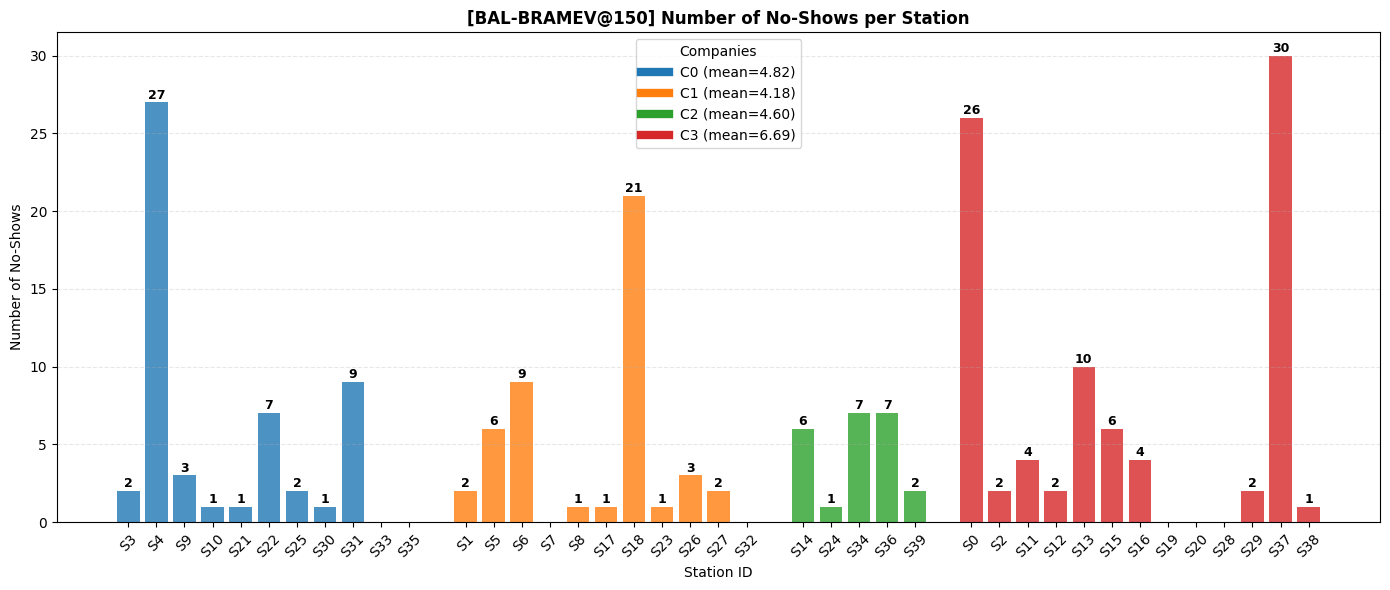

In [104]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [105]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,9,7,2,0,0,0.777778,0.222222,0.0,0.0
1,0,4,104,76,27,0,0,0.730769,0.259615,0.0,0.0
2,0,9,10,7,3,0,0,0.700000,0.300000,0.0,0.0
3,0,10,9,8,1,0,0,0.888889,0.111111,0.0,0.0
4,0,21,6,5,1,0,0,0.833333,0.166667,0.0,0.0
5,0,22,53,45,7,0,0,0.849057,0.132075,0.0,0.0
6,0,25,6,4,2,0,0,0.666667,0.333333,0.0,0.0
7,0,30,6,5,1,0,0,0.833333,0.166667,0.0,0.0
8,0,31,61,50,9,0,0,0.819672,0.147541,0.0,0.0
9,0,33,9,8,0,0,0,0.888889,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [106]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

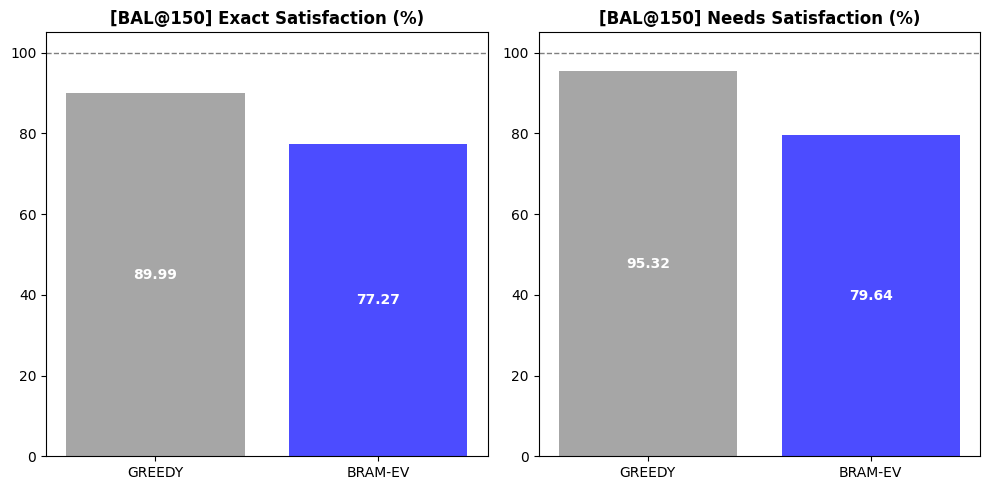

In [107]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

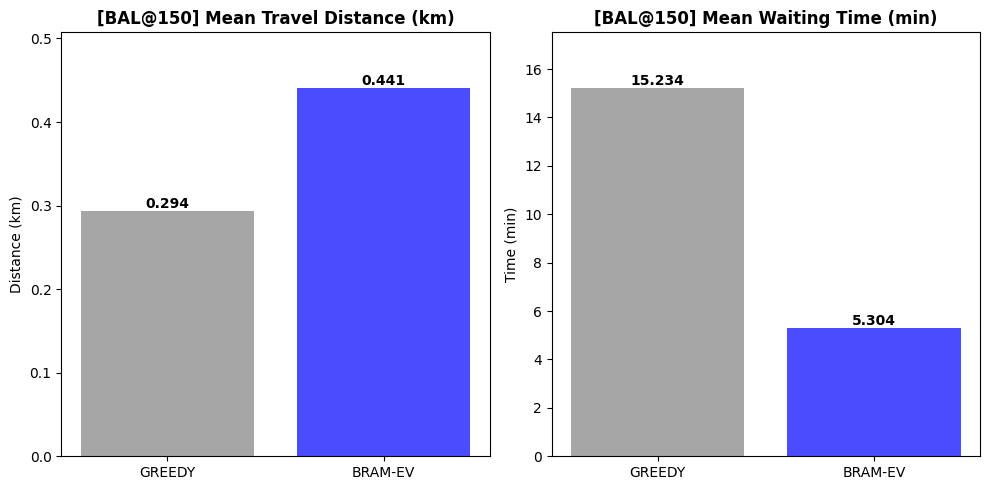

In [108]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

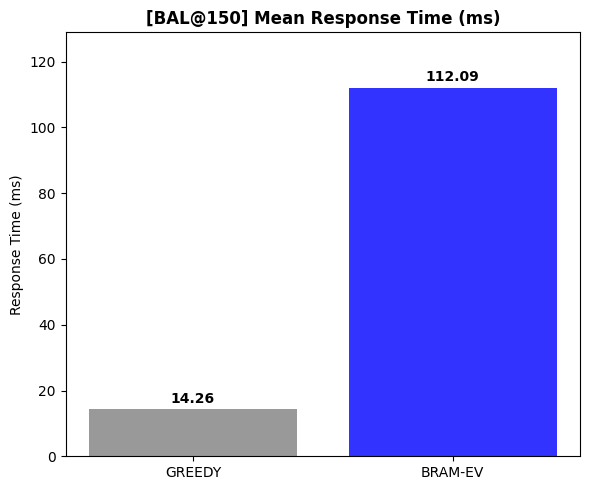

In [109]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [110]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [111]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/200cars


##### *Initialisation*

In [112]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [113]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:15:40.225 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:15:40.378 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:15:40.666 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:15:40.889 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:15:41.151 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:15:41.473 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:15:41.684 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:15:42.145 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:15:42.461 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:15:42.823 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:15:42.974 | IN

##### *Metrics*

In [114]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 97.47 kWh
  Station 1: 5.22 kWh
  Station 2: 30.52 kWh
  Station 3: 15.55 kWh
  Station 4: 1.65 kWh
  Station 5: 223.77 kWh
  Station 6: 108.71 kWh
  Station 7: 16.18 kWh
  Station 8: 76.28 kWh
  Station 9: 5.99 kWh
  Station 10: 2.54 kWh
  Station 11: 4.71 kWh
  Station 12: 7.25 kWh
  Station 13: 12.32 kWh
  Station 14: 99.47 kWh
  Station 15: 7.00 kWh
  Station 16: 16.80 kWh
  Station 17: 66.93 kWh
  Station 18: 9.32 kWh
  Station 19: 257.96 kWh
  Station 20: 34.11 kWh
  Station 21: 5.62 kWh
  Station 22: 9.68 kWh
  Station 23: 9.85 kWh
  Station 24: 2.63 kWh
  Station 25: 32.61 kWh
  Station 26: 98.90 kWh
  Station 27: 4.72 kWh
  Station 28: 6.62 kWh
  Station 29: 330.35 kWh
  Station 30: 57.37 kWh
  Station 31: 16.70 kWh
  Station 32: 285.01 kWh
  Station 33: 4.92 kWh
  Station 34: 14.33 kWh
  Station 35: 5.48 kWh
  Station 36: 4.97 kWh
  Station 37: 6.38 kWh
  Station 38: 145.55 kWh
  Station 39: 16.94 kWh

In [115]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

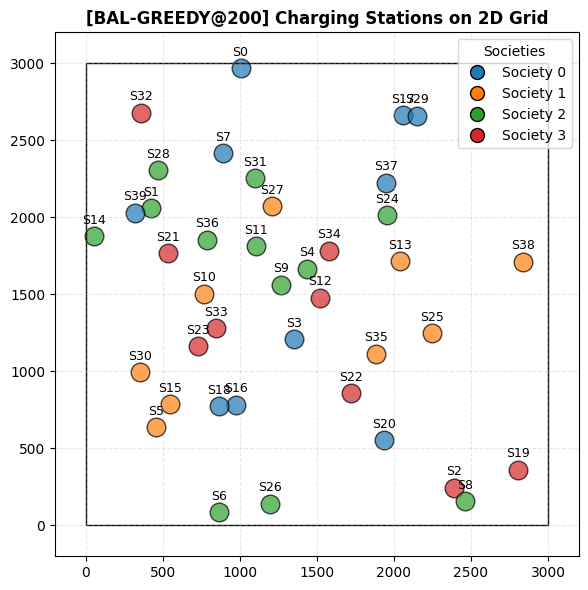

In [116]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

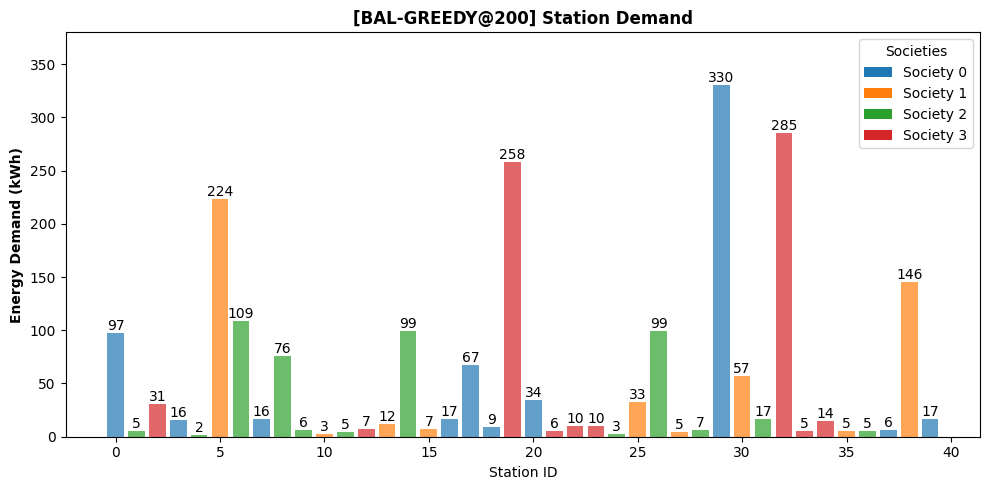

In [117]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

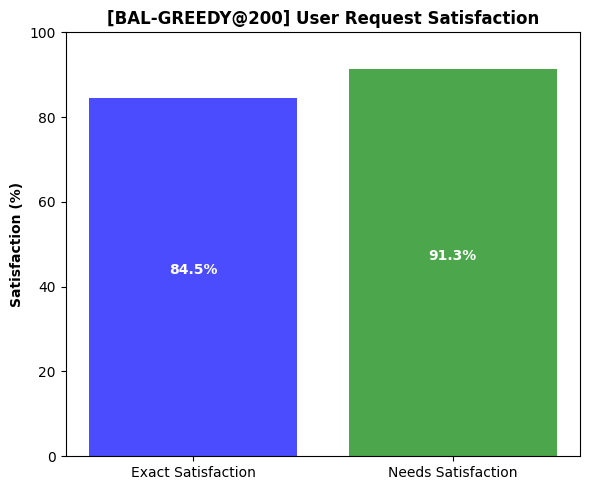

In [118]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

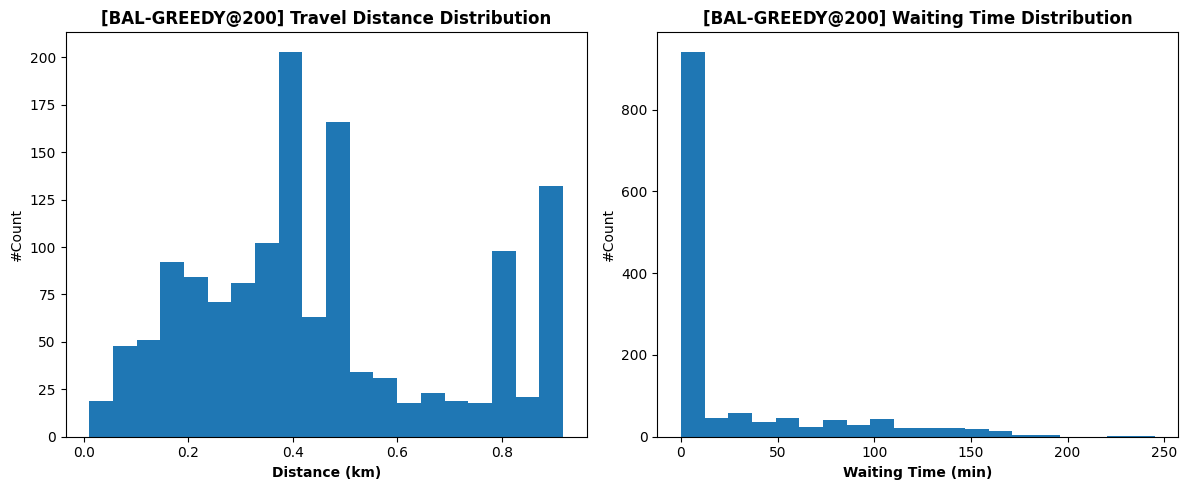

In [119]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

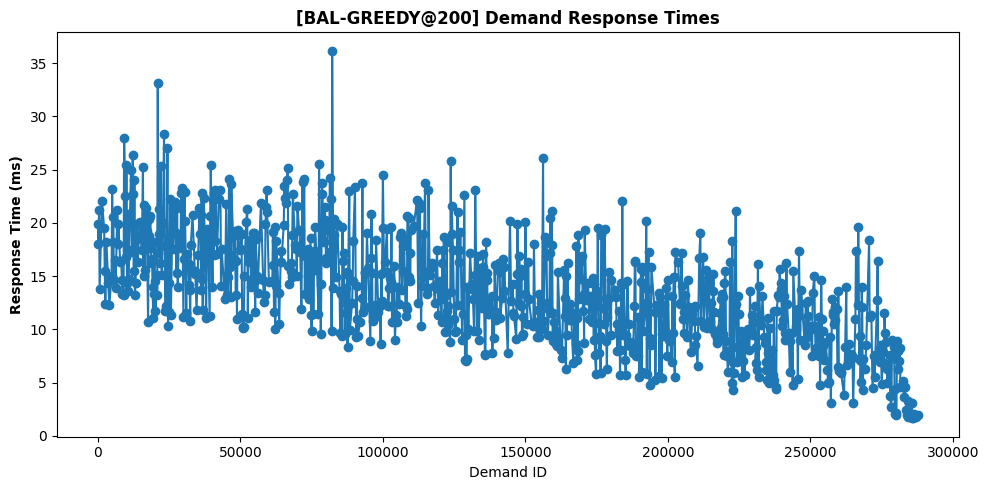

In [120]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

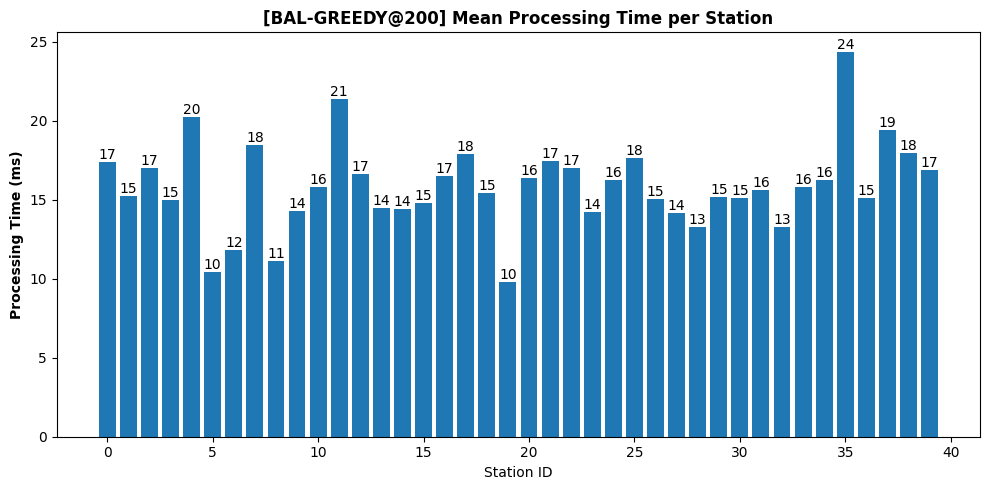

In [121]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [122]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [123]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [124]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:16:08.820 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:16:10.804 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:16:12.418 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:16:13.823 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:16:15.741 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:16:17.521 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:16:19.838 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:16:21.635 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:16:23.460 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:16:25.234 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:16:26.139 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [125]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 200.18 kWh
  Station 1: 271.07 kWh
  Station 2: 37.45 kWh
  Station 3: 77.58 kWh
  Station 4: 124.32 kWh
  Station 5: 13.07 kWh
  Station 6: 84.64 kWh
  Station 7: 17.38 kWh
  Station 8: 10.04 kWh
  Station 9: 71.71 kWh
  Station 10: 46.70 kWh
  Station 11: 18.72 kWh
  Station 12: 37.90 kWh
  Station 13: 3.53 kWh
  Station 14: 108.75 kWh
  Station 15: 12.05 kWh
  Station 16: 59.94 kWh
  Station 17: 19.44 kWh
  Station 18: 6.10 kWh
  Station 19: 4.97 kWh
  Station 20: 7.88 kWh
  Station 21: 9.84 kWh
  Station 22: 8.98 kWh
  Station 23: 79.17 kWh
  Station 24: 17.79 kWh
  Station 25: 20.01 kWh
  Station 26: 147.29 kWh
  Station 27: 54.10 kWh
  Station 28: 73.62 kWh
  Station 29: 154.13 kWh
  Station 30: 7.38 kWh
  Station 31: 3.75 kWh
  Station 32: 23.27 kWh
  Station 33: 76.44 kWh
  Station 34: 72.02 kWh
  Station 35: 40.17 kWh
  Station 36: 10.51 kWh
  Station 37: 16.88 kWh
  Station 38: 9.51 kWh
  Station 39: 

In [126]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

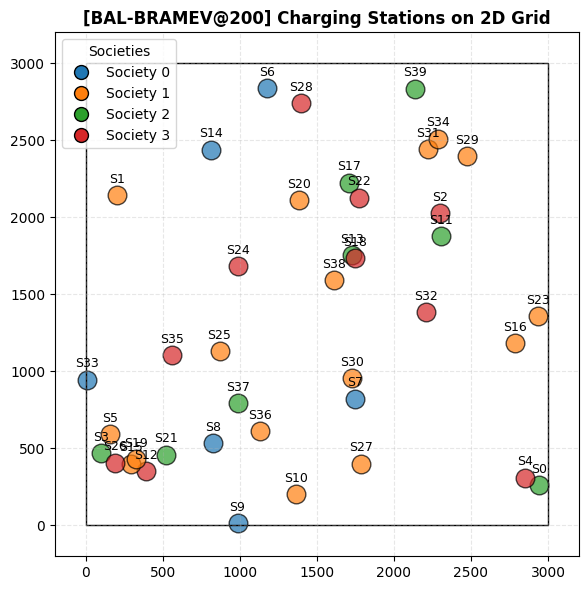

In [127]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

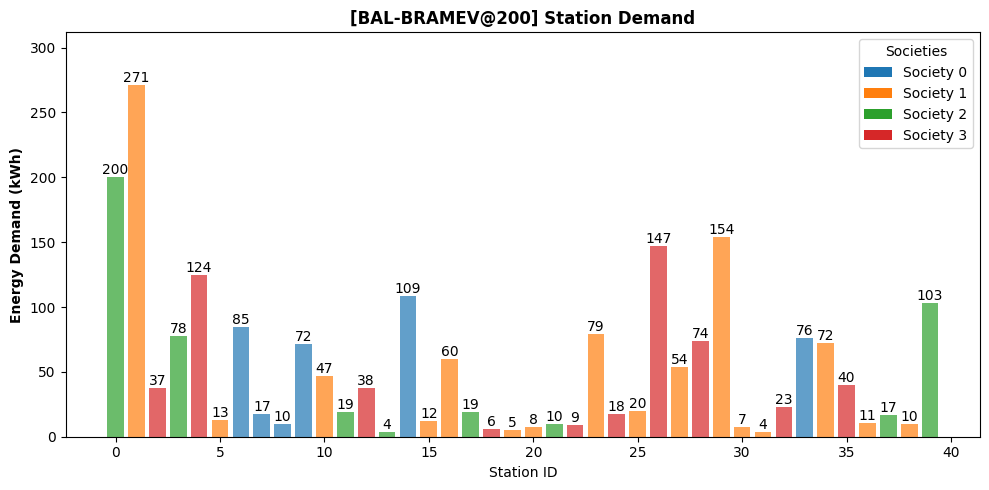

In [128]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

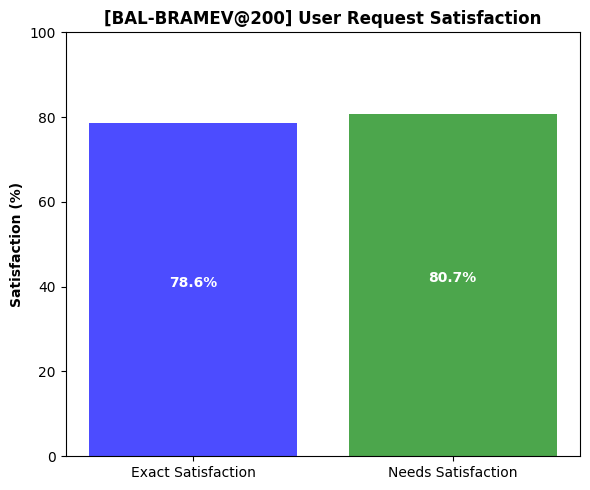

In [129]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

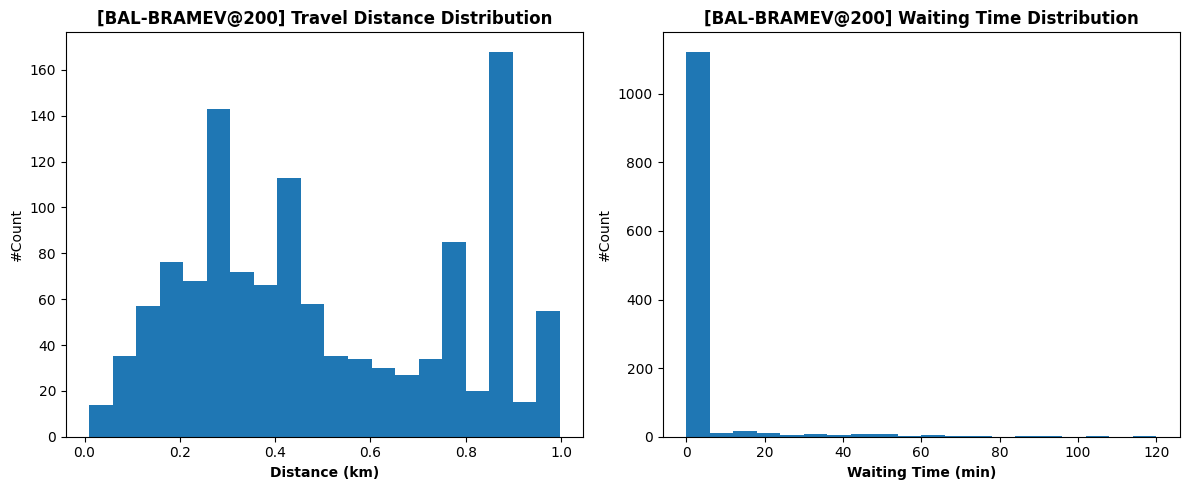

In [130]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

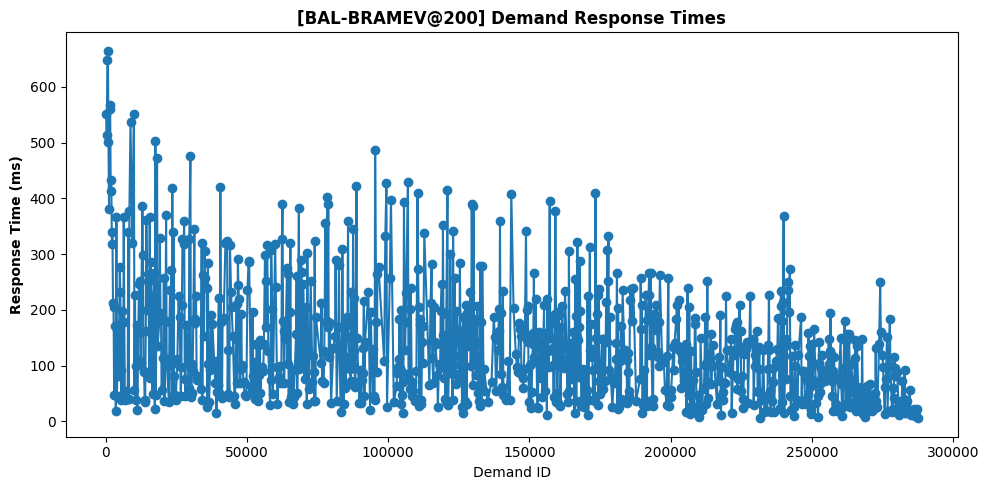

In [131]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

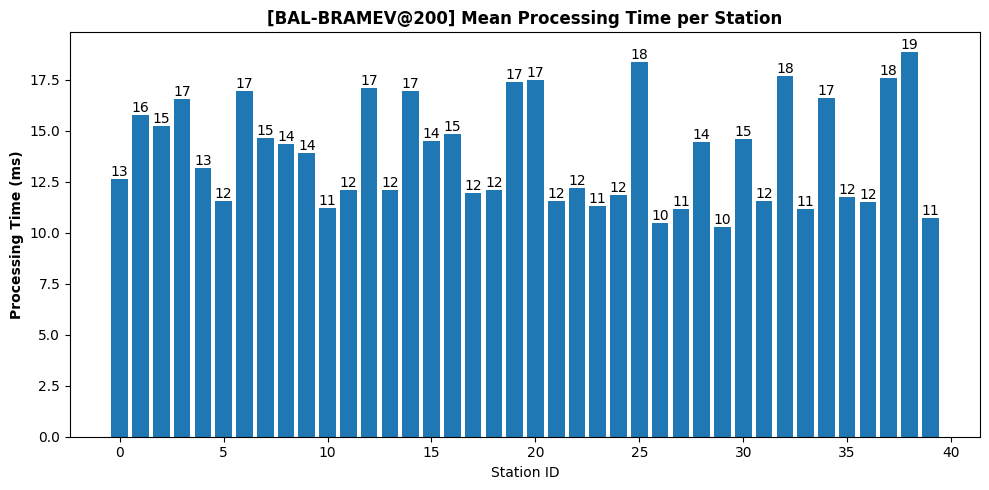

In [132]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

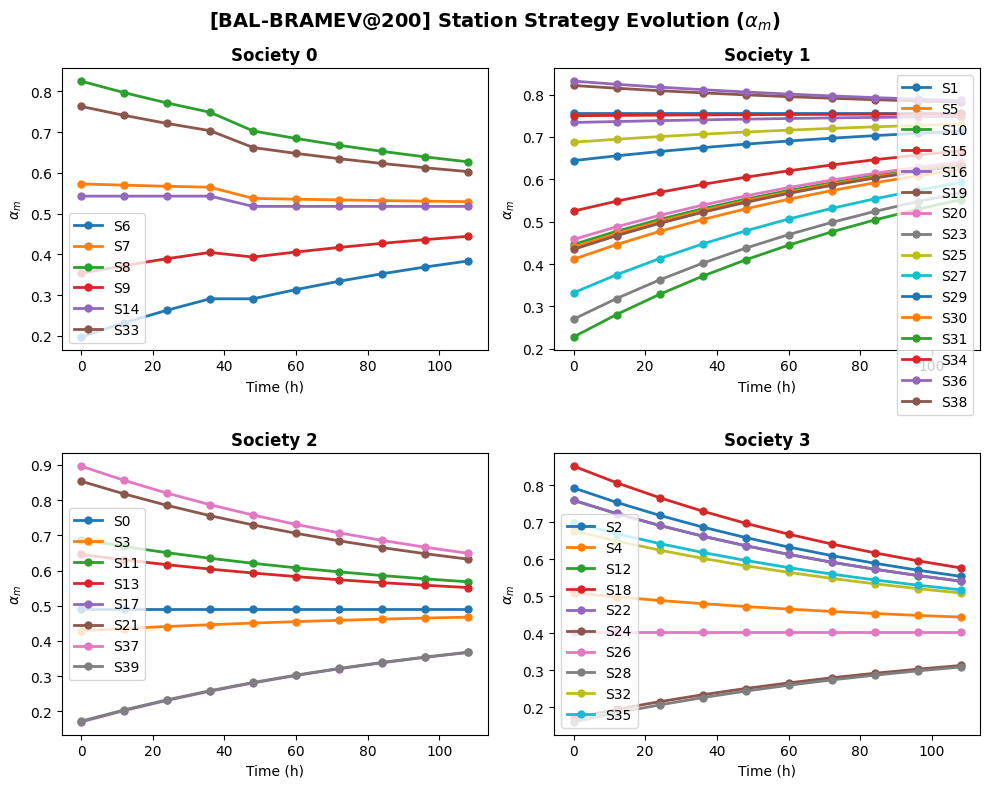

In [133]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [134]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           6  0.514583  0.370139  0.088194  0.048611  0.081944   
1            0           7  0.127778  0.094444  0.027083  0.000000  0.000000   
2            0           8  0.147222  0.034722  0.000000  0.000000  0.000000   
3            0           9  0.447917  0.288194  0.119444  0.019444  0.129167   
4            0          14  0.584028  0.418056  0.259028  0.056944  0.150694   
5            0          33  0.521528  0.314583  0.116667  0.181944       NaN   
6            1           1  0.798611  0.765972  0.520833  0.568750  0.631250   
7            1           5  0.165278  0.016667  0.011806  0.000000       NaN   
8            1          10  0.359028  0.145139  0.081250  0.030556       NaN   
9            1          15  0.138889  0.042361  0.000000  0.000000  0.000000   
10           1          16  0.534028  0.165278  0.045139  0.000000  0.081250   
11           1          19  0.068750  0.

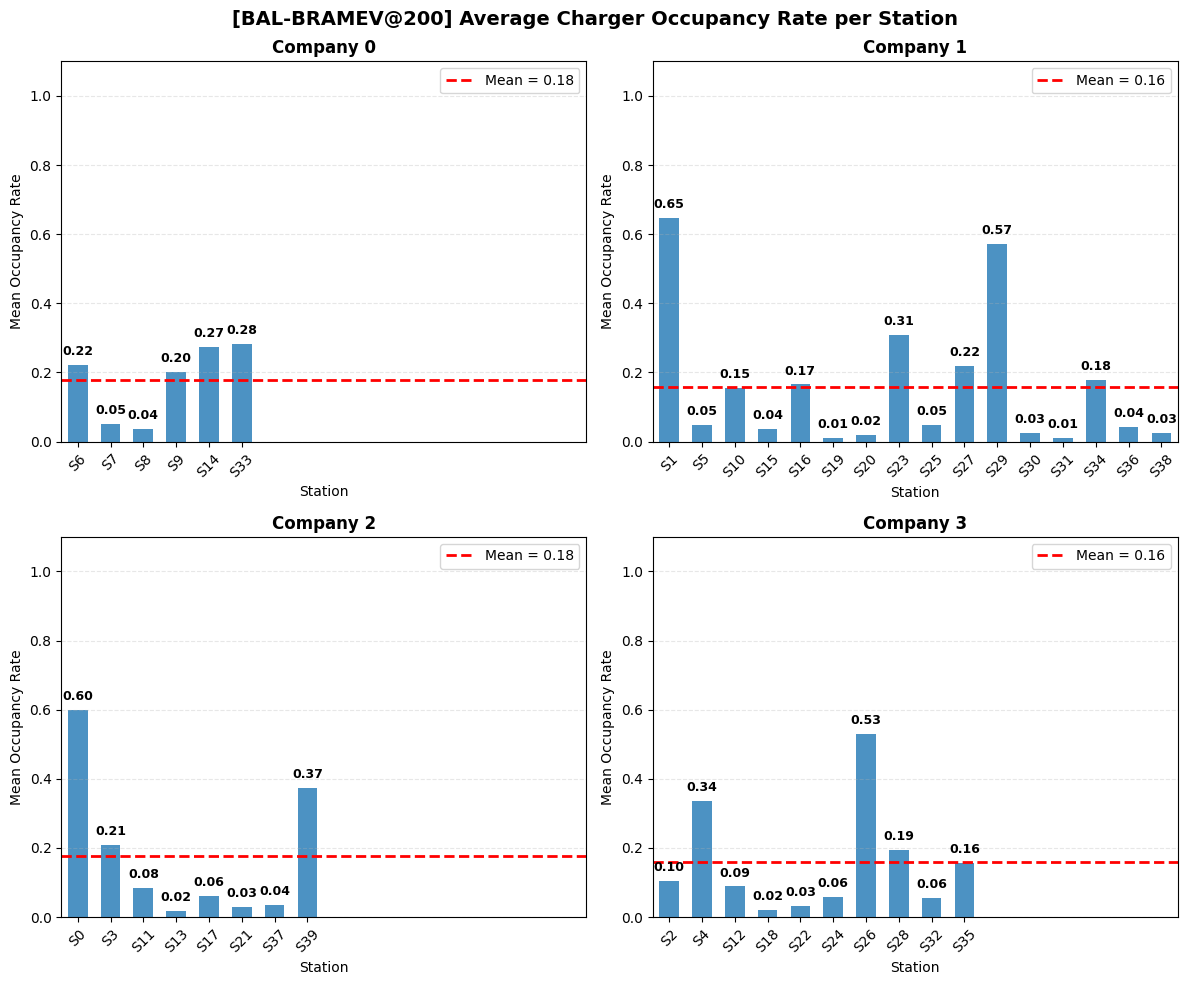

In [135]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

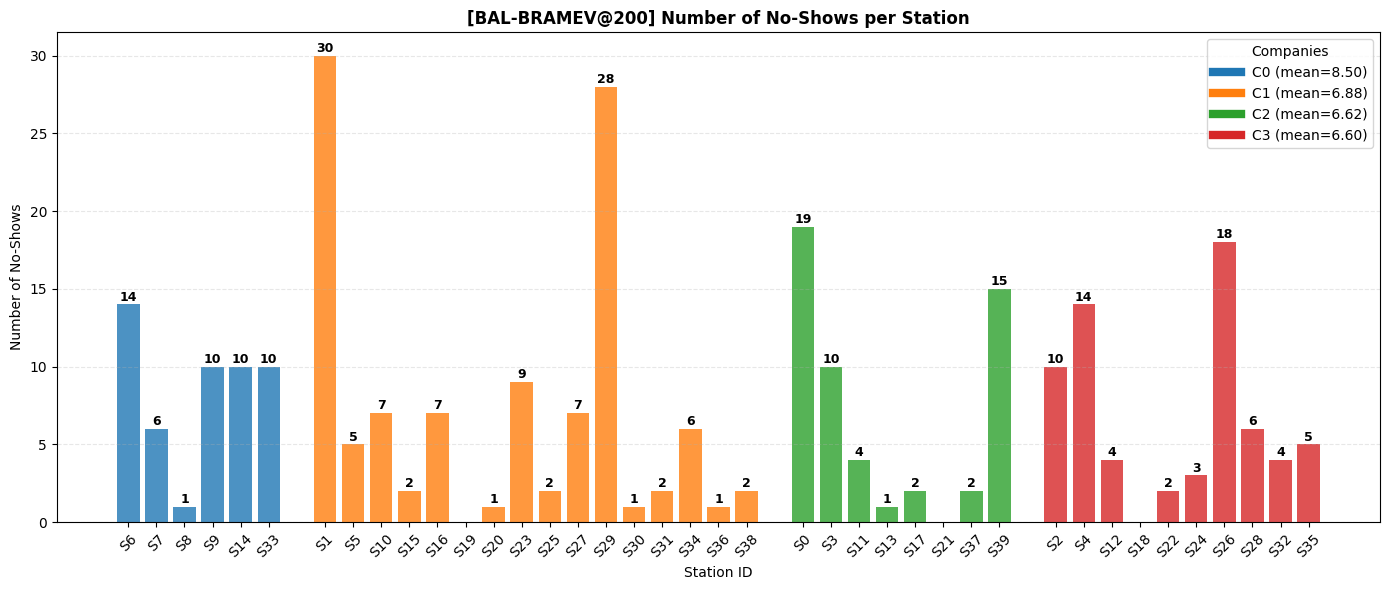

In [136]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [137]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,6,64,49,14,0,0,0.765625,0.218750,0.0,0.0
1,0,7,16,10,6,0,0,0.625000,0.375000,0.0,0.0
2,0,8,7,6,1,0,0,0.857143,0.142857,0.0,0.0
3,0,9,49,39,10,0,0,0.795918,0.204082,0.0,0.0
4,0,14,71,60,10,0,0,0.845070,0.140845,0.0,0.0
5,0,33,55,44,10,0,0,0.800000,0.181818,0.0,0.0
6,1,1,187,154,30,0,0,0.823529,0.160428,0.0,0.0
7,1,5,13,8,5,0,0,0.615385,0.384615,0.0,0.0
8,1,10,33,26,7,0,0,0.787879,0.212121,0.0,0.0
9,1,15,8,6,2,0,0,0.750000,0.250000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [138]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

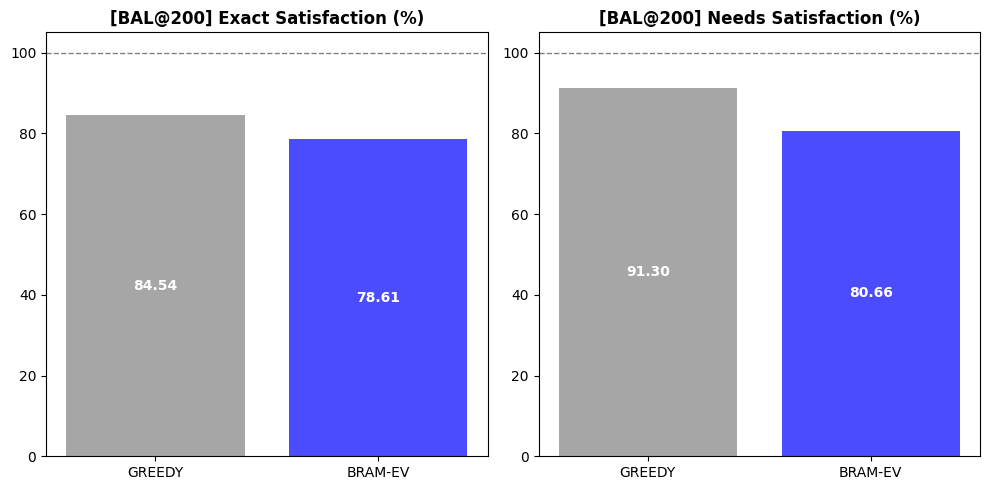

In [139]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

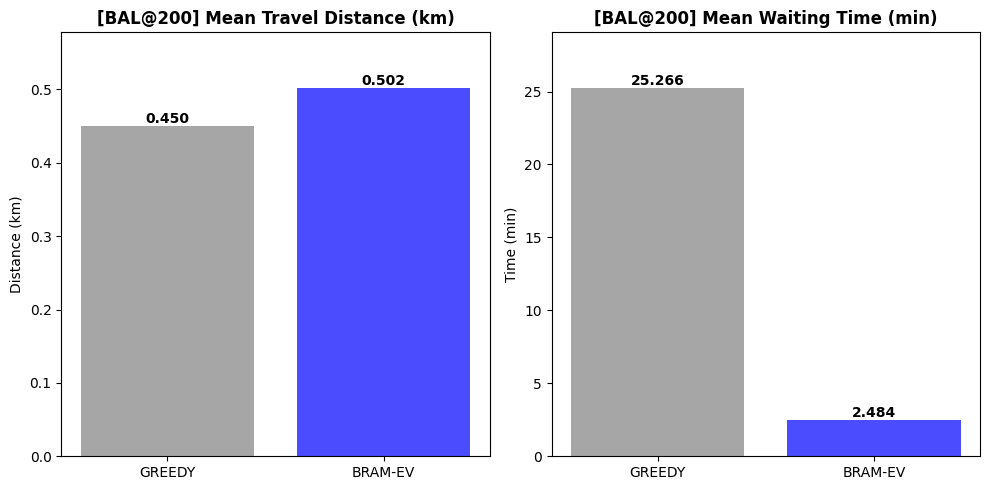

In [140]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

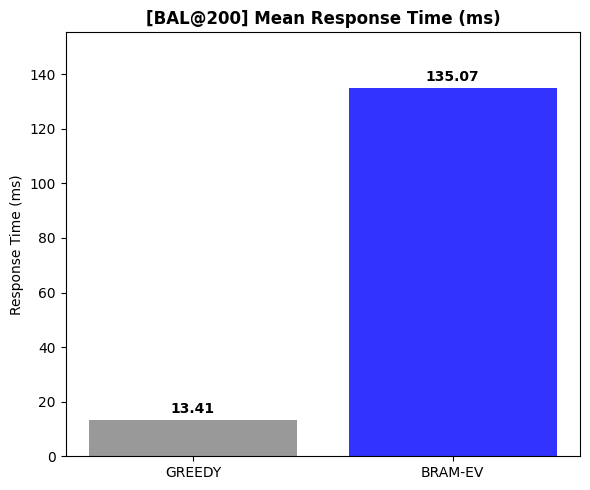

In [141]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [142]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [143]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance/greedy/250cars


##### *Initialisation*

In [144]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [145]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:18:20.772 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:18:21.084 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:18:21.354 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:18:21.631 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:18:21.869 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:18:22.352 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:18:22.664 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:18:23.083 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:18:23.411 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:18:23.722 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:18:23.961 | IN

##### *Metrics*

In [146]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 111.97 kWh
  Station 1: 82.03 kWh
  Station 2: 31.65 kWh
  Station 3: 19.63 kWh
  Station 4: 63.23 kWh
  Station 5: 43.99 kWh
  Station 6: 67.14 kWh
  Station 7: 111.89 kWh
  Station 8: 9.00 kWh
  Station 9: 115.08 kWh
  Station 10: 26.62 kWh
  Station 11: 87.33 kWh
  Station 12: 7.80 kWh
  Station 13: 73.13 kWh
  Station 14: 6.61 kWh
  Station 15: 250.08 kWh
  Station 16: 7.12 kWh
  Station 17: 56.39 kWh
  Station 18: 12.31 kWh
  Station 19: 87.49 kWh
  Station 20: 15.95 kWh
  Station 21: 29.49 kWh
  Station 22: 14.18 kWh
  Station 23: 11.91 kWh
  Station 24: 355.37 kWh
  Station 25: 50.80 kWh
  Station 26: 45.44 kWh
  Station 27: 86.96 kWh
  Station 28: 8.52 kWh
  Station 29: 96.52 kWh
  Station 30: 11.03 kWh
  Station 31: 14.95 kWh
  Station 32: 250.74 kWh
  Station 33: 26.01 kWh
  Station 34: 22.57 kWh
  Station 35: 10.25 kWh
  Station 36: 11.31 kWh
  Station 37: 0.00 kWh
  Station 38: 13.16 kWh
  Station 3

In [147]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

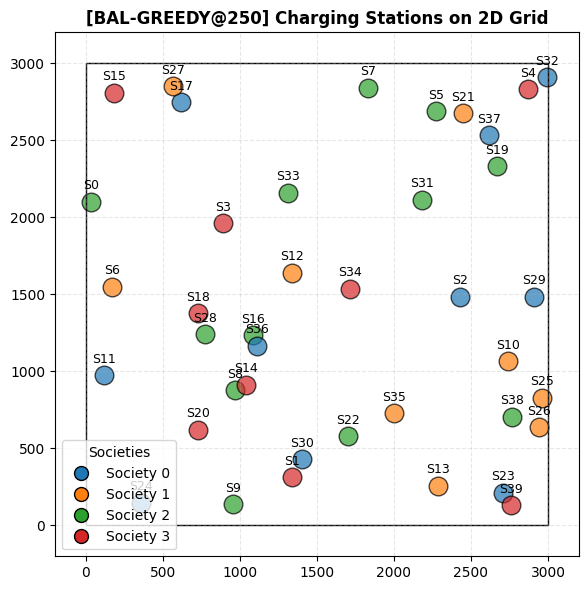

In [148]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

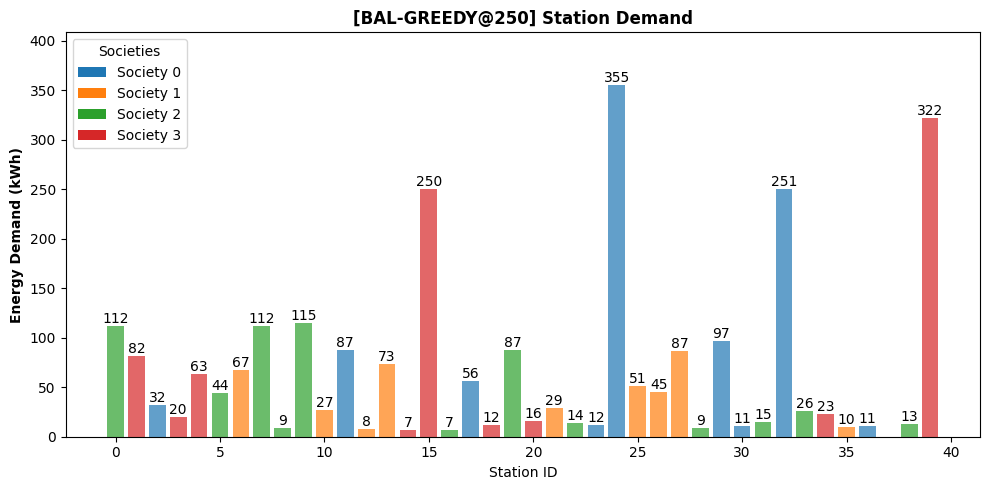

In [149]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

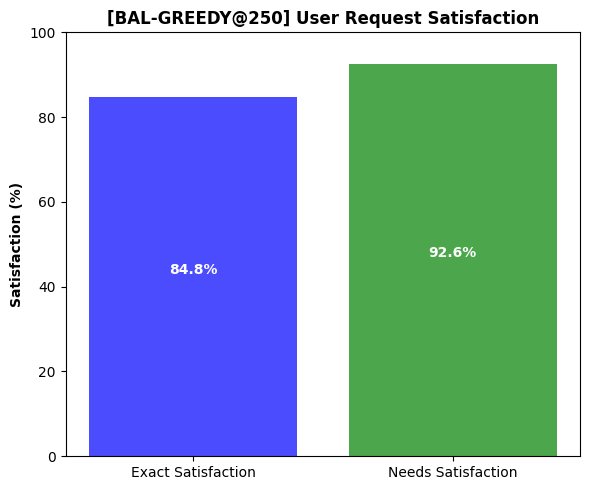

In [150]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

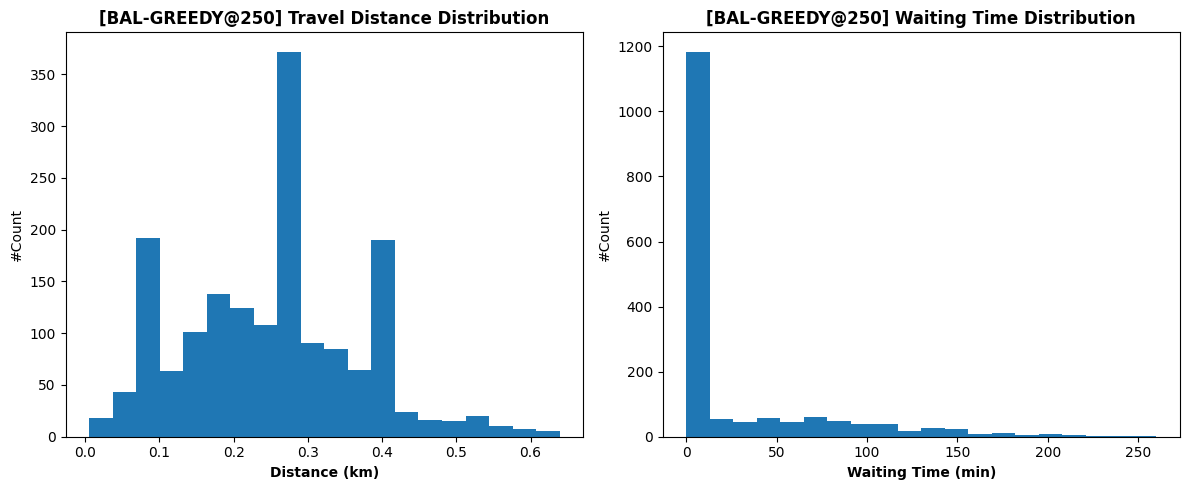

In [151]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

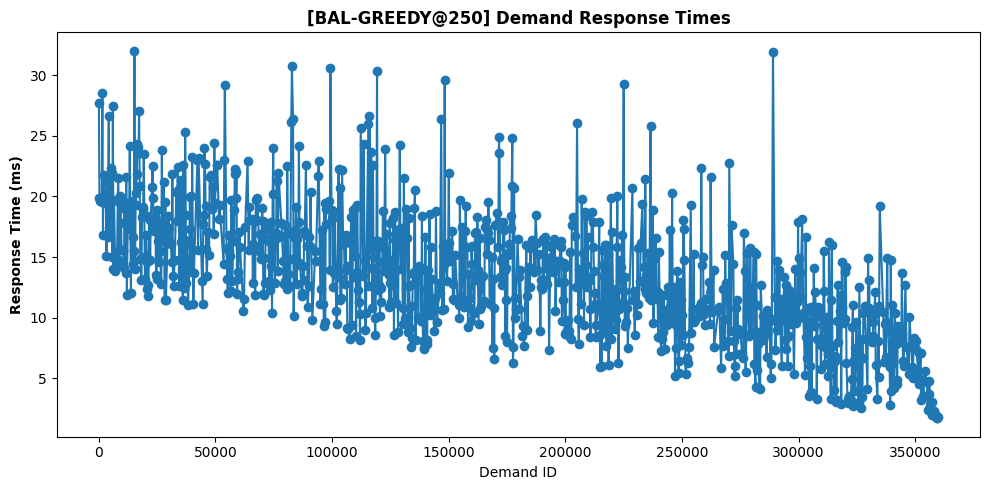

In [152]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

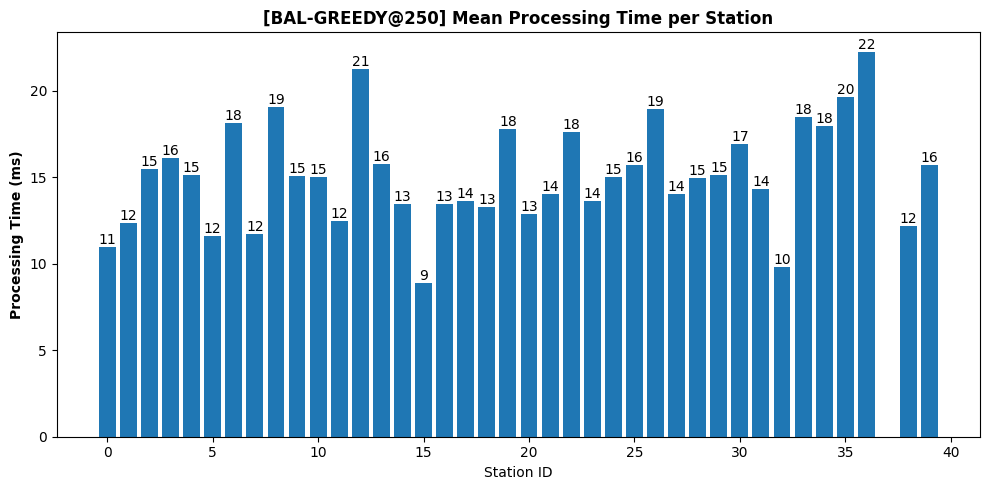

In [153]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [154]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [155]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [156]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:18:54.638 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:19:03.197 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:19:08.451 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:19:10.600 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:19:12.235 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:19:15.857 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:19:18.900 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:19:21.825 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:19:24.573 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:19:26.156 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:19:28.774 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [157]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 95.73 kWh
  Station 1: 173.17 kWh
  Station 2: 43.82 kWh
  Station 3: 28.40 kWh
  Station 4: 23.74 kWh
  Station 5: 52.62 kWh
  Station 6: 46.14 kWh
  Station 7: 108.97 kWh
  Station 8: 72.99 kWh
  Station 9: 7.58 kWh
  Station 10: 6.44 kWh
  Station 11: 197.27 kWh
  Station 12: 69.04 kWh
  Station 13: 72.88 kWh
  Station 14: 149.19 kWh
  Station 15: 106.19 kWh
  Station 16: 70.91 kWh
  Station 17: 19.20 kWh
  Station 18: 13.68 kWh
  Station 19: 65.67 kWh
  Station 20: 53.98 kWh
  Station 21: 23.70 kWh
  Station 22: 82.72 kWh
  Station 23: 27.62 kWh
  Station 24: 15.84 kWh
  Station 25: 40.85 kWh
  Station 26: 69.47 kWh
  Station 27: 140.22 kWh
  Station 28: 108.48 kWh
  Station 29: 14.70 kWh
  Station 30: 57.25 kWh
  Station 31: 194.86 kWh
  Station 32: 26.18 kWh
  Station 33: 20.76 kWh
  Station 34: 13.46 kWh
  Station 35: 49.05 kWh
  Station 36: 282.70 kWh
  Station 37: 50.04 kWh
  Station 38: 5.47 kWh
  Sta

In [158]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

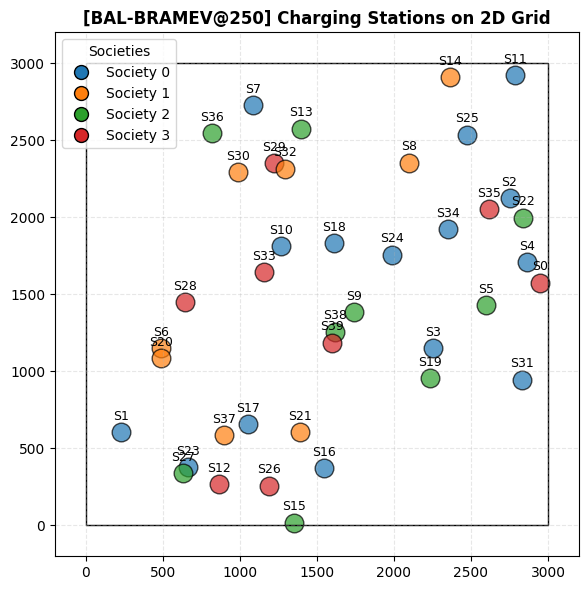

In [159]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

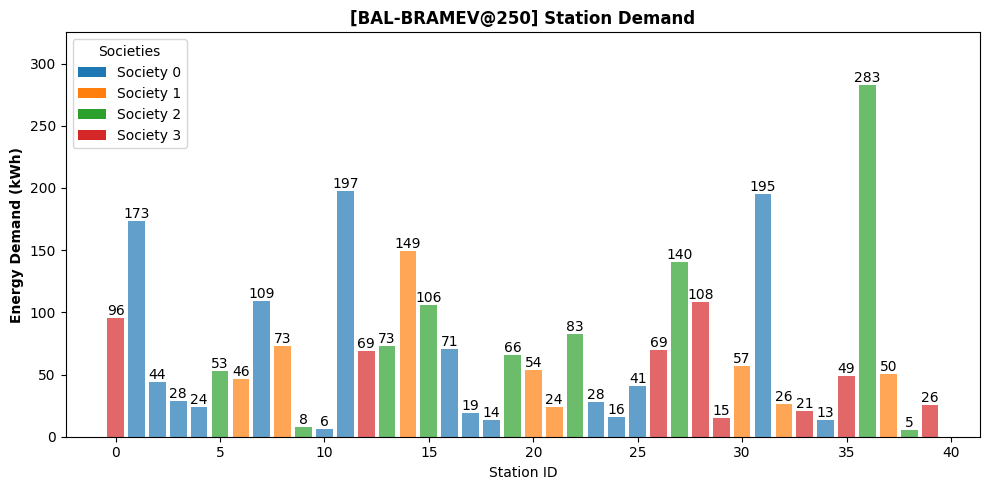

In [160]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

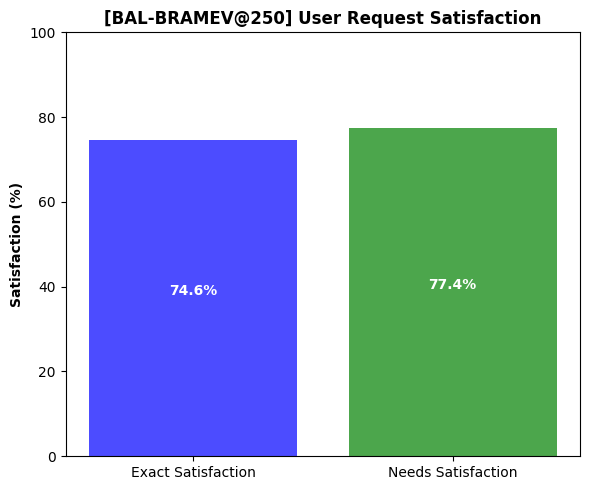

In [161]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

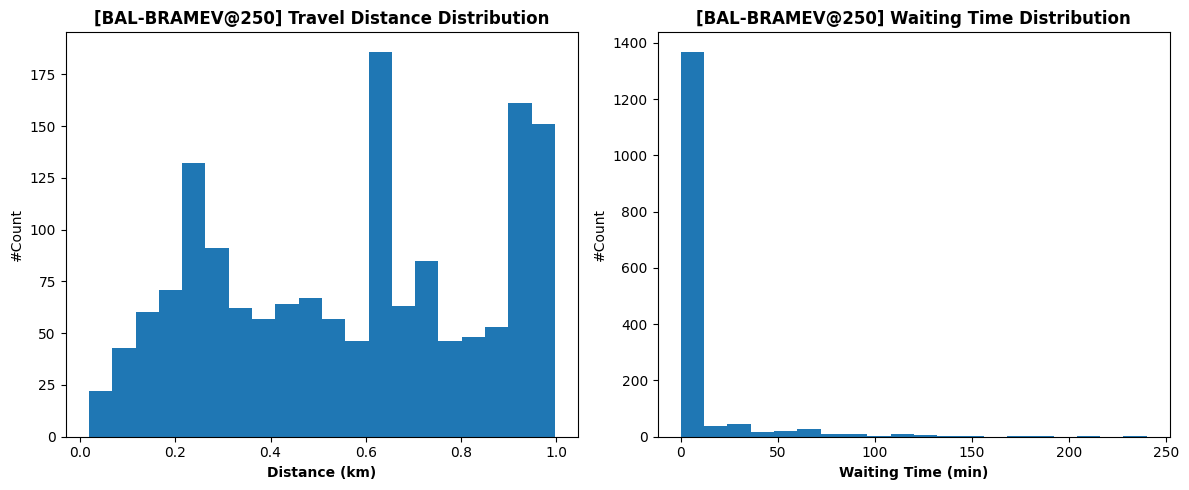

In [162]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

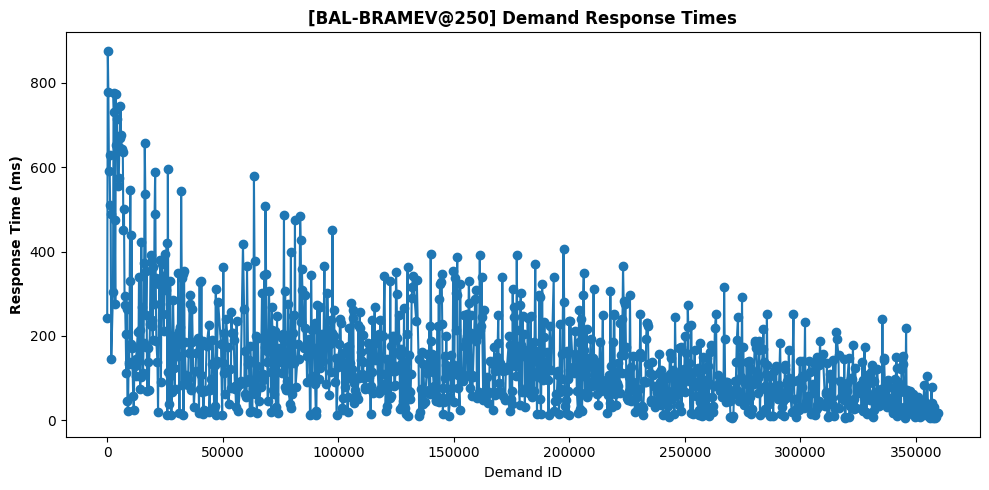

In [163]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

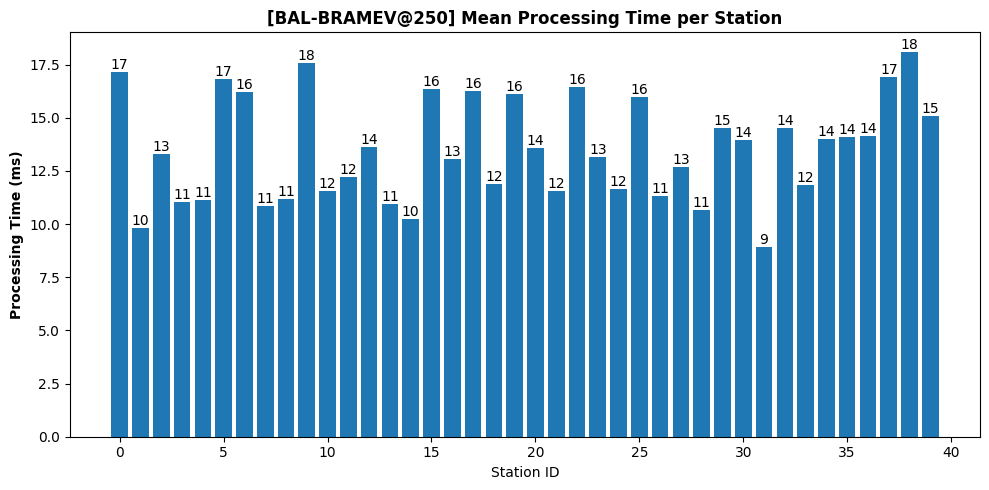

In [164]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

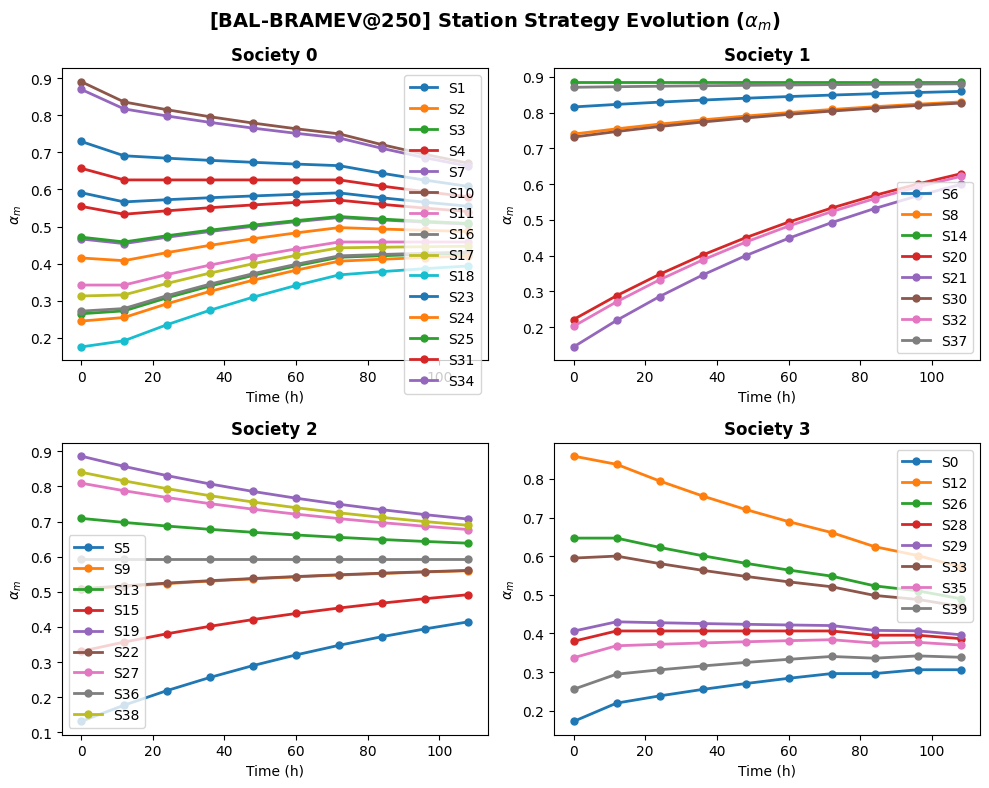

In [165]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [166]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.694444  0.667361  0.522917  0.609722       NaN   
1            0           2  0.380556  0.184028  0.000000  0.000000  0.069444   
2            0           3  0.243750  0.050694  0.045139  0.017361       NaN   
3            0           4  0.214583  0.102083  0.015972  0.000000       NaN   
4            0           7  0.565278  0.276389  0.306250  0.325694       NaN   
5            0          10  0.088194  0.000000  0.000000  0.000000       NaN   
6            0          11  0.620833  0.657639  0.443056  0.533333  0.672917   
7            0          16  0.535417  0.225694  0.118750  0.014583  0.104167   
8            0          17  0.200000  0.052778  0.000000  0.000000  0.000000   
9            0          18  0.095139  0.052083  0.019444  0.025694       NaN   
10           0          23  0.202083  0.142361  0.000000  0.020833  0.038194   
11           0          24  0.160417  0.

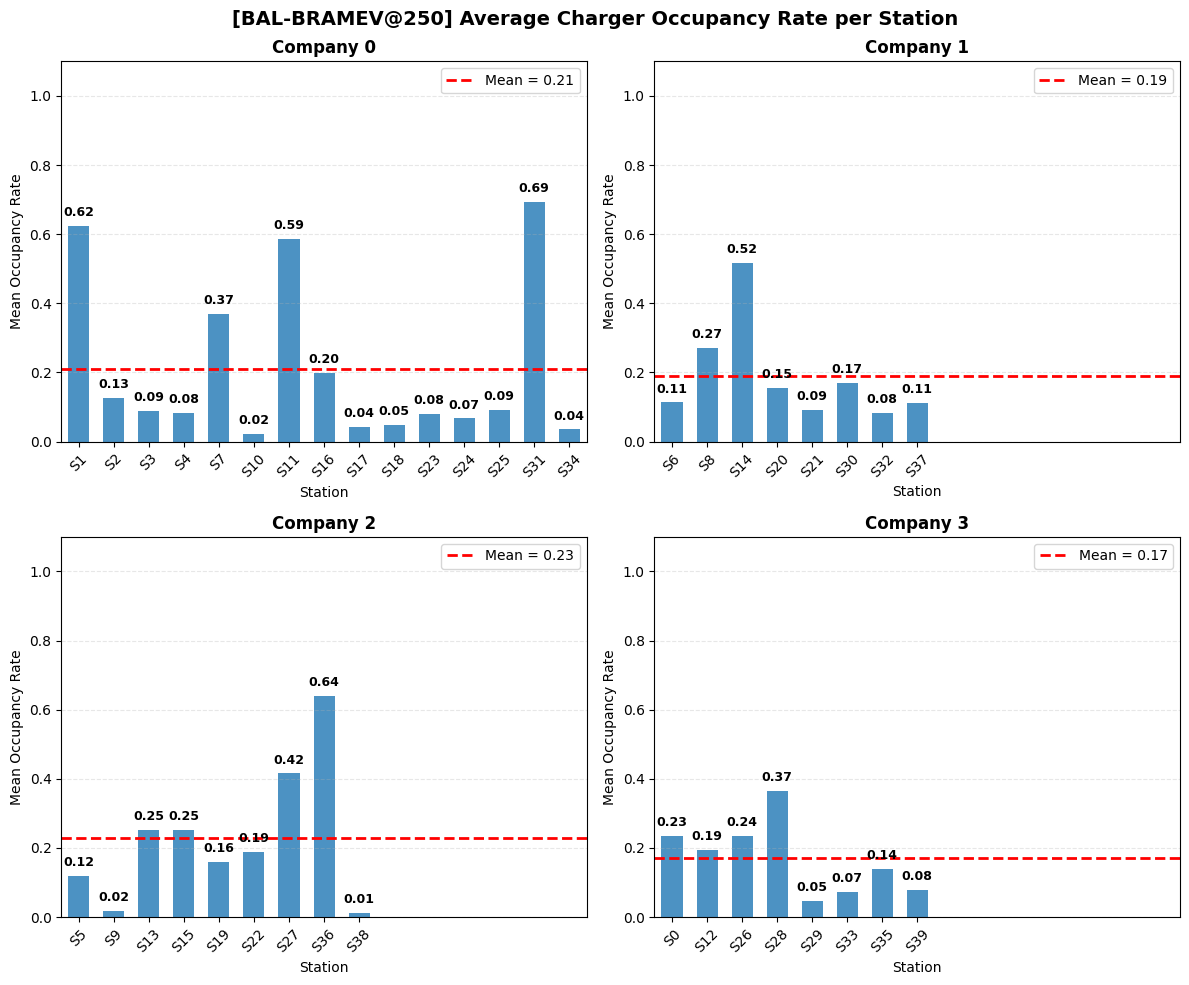

In [167]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

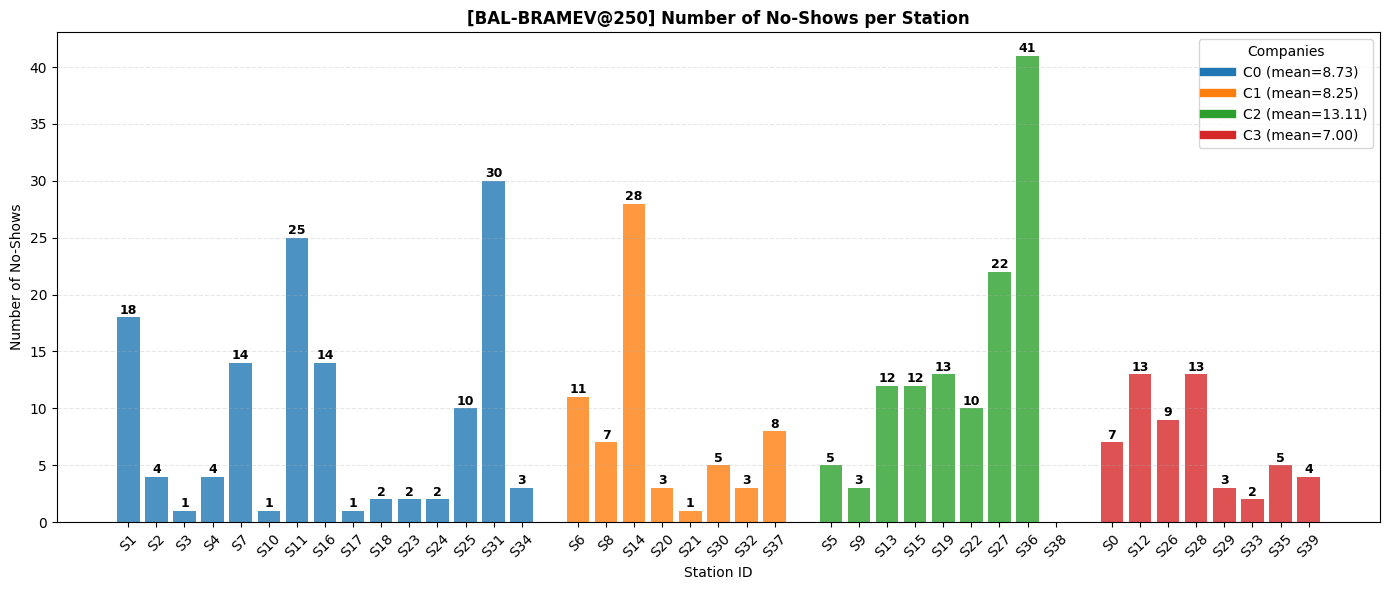

In [168]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [169]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,118,99,18,0,0,0.838983,0.152542,0.000000,0.000000
1,0,2,28,24,4,0,0,0.857143,0.142857,0.000000,0.000000
2,0,3,17,16,1,0,0,0.941176,0.058824,0.000000,0.000000
3,0,4,19,15,4,0,0,0.789474,0.210526,0.000000,0.000000
4,0,7,74,60,14,0,0,0.810811,0.189189,0.000000,0.000000
5,0,10,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
6,0,11,134,109,25,0,0,0.813433,0.186567,0.000000,0.000000
7,0,16,55,40,14,0,0,0.727273,0.254545,0.000000,0.000000
8,0,17,12,11,1,0,0,0.916667,0.083333,0.000000,0.000000
9,0,18,10,8,2,0,0,0.800000,0.200000,0.000000,0.000000


#### **COMPARISON**

##### *Params*

In [170]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

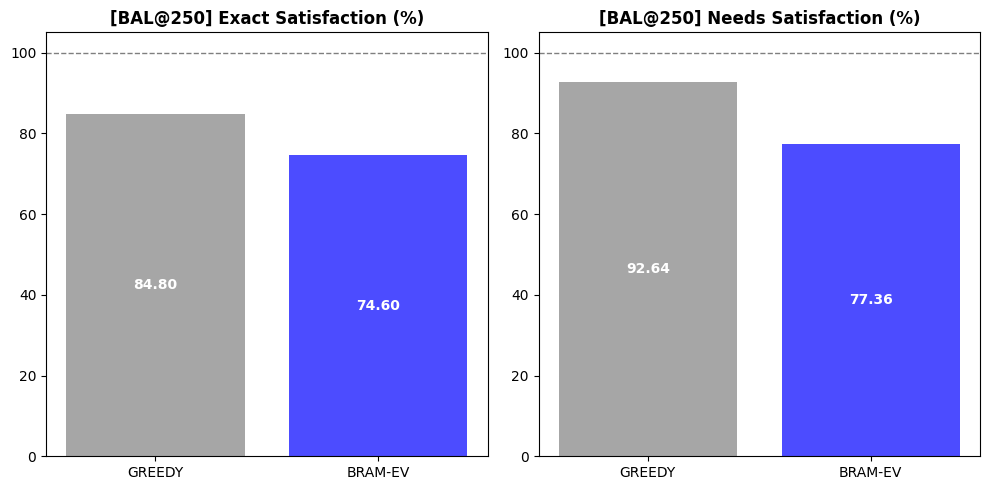

In [171]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

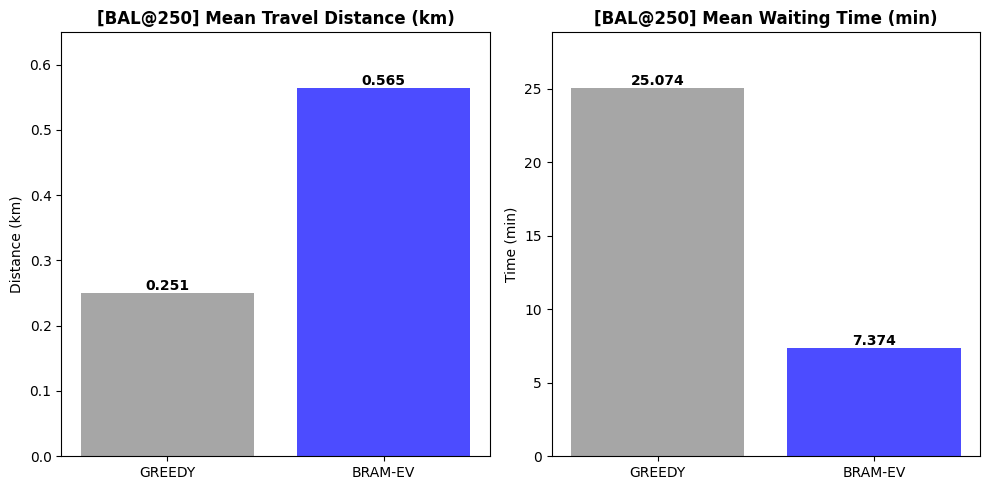

In [172]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

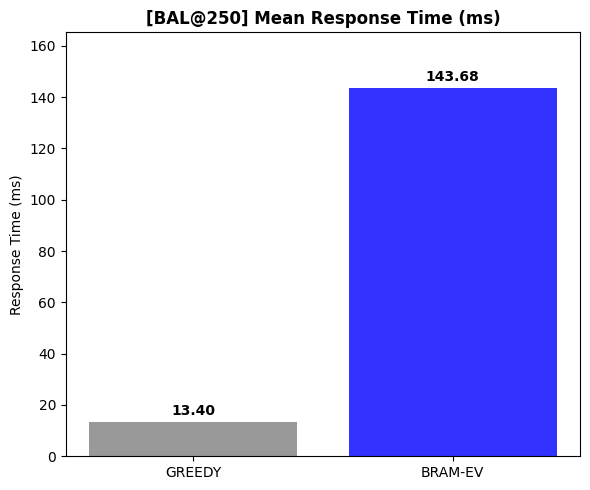

In [173]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

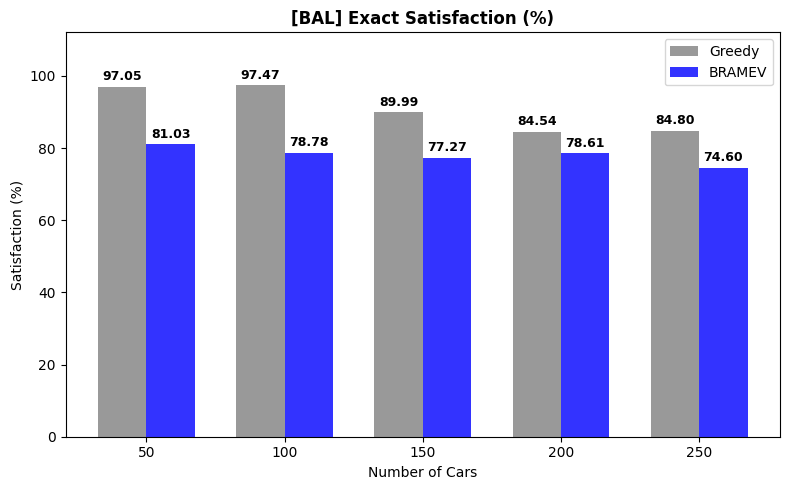

In [174]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

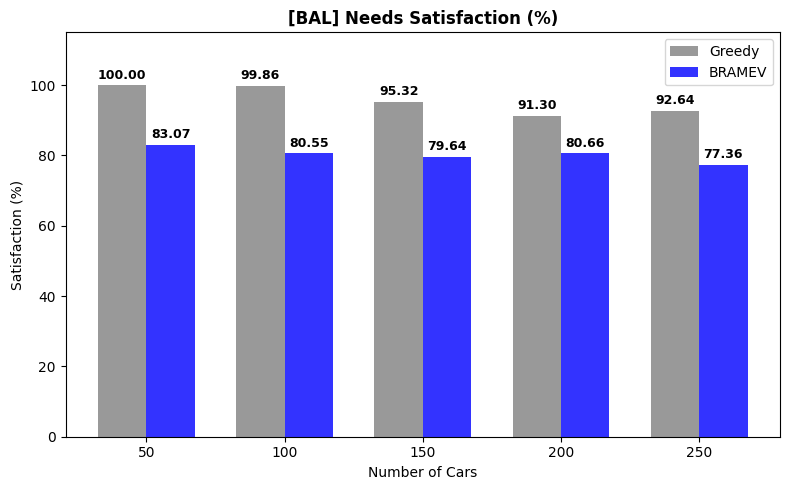

In [175]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

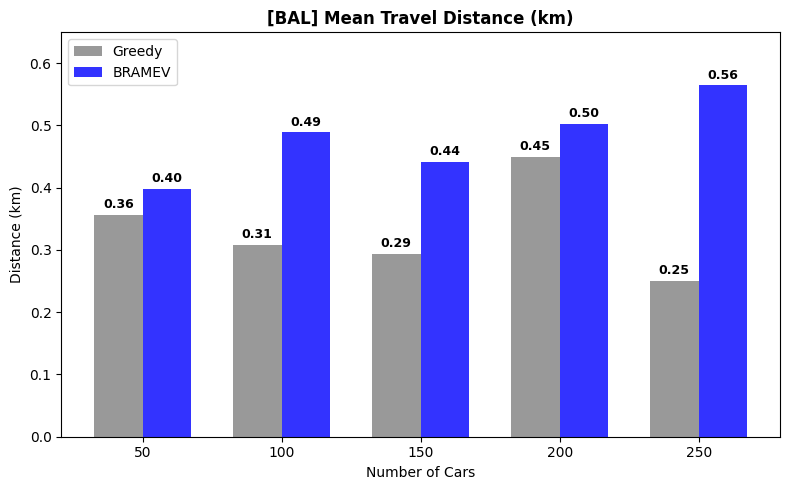

In [176]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


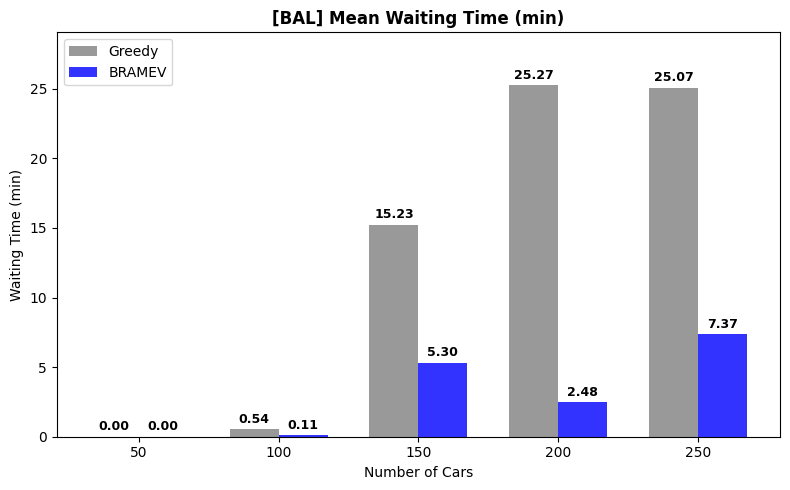

In [177]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


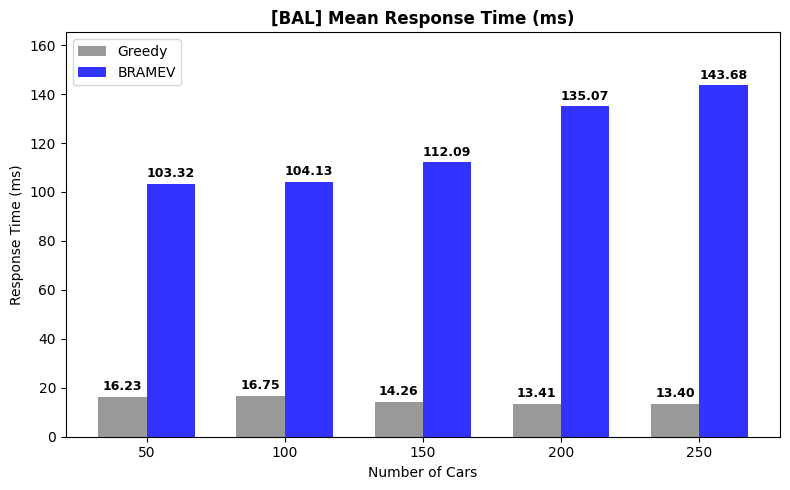

In [178]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
